<a href="https://colab.research.google.com/github/eospgonz10/statistical_analytics_homicide/blob/main/sesiones_practicas/trabajo_final_juan_jose_garcia_alvarez_estiven_ospina_gonzalez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:Black;"><strong>Introducción</strong></span>

<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b>1. Breve presentación del problema o pregunta de investigación.</b>  
</div>

¿Qué factores sociales, demográficos y geográficos influyen en las tendencias de homicidios en Estados Unidos?

<br>
<div style="background-color:#E8F5E9; padding:10px; border-radius:8px;">
<b> 2. Contexto: ¿por qué es relevante este problema?</b>  
</div>

Los **homicidios** constituyen una de las principales causas de mortalidad prevenible en Estados Unidos, con profundas implicaciones sociales, económicas y de salud pública. Más allá de las cifras, este fenómeno puede refleja desigualdades estructurales y vulnerabilidades en segmentos específicos de la población.

Comprender qué factores influyen en las tendencias de homicidios es relevante por varias razones:

- **Vulnerabilidad geográfica**: Existen zonas marginadas y con menor acceso a servicios de seguridad y bienestar donde la incidencia de homicidios es significativamente mayor.
- **Disparidades demográficas**: Ciertos grupos étnicos y por sexo pueden presentarse víctimas en proporciones desequilibradas, lo que requiere análisis diferenciado.
- **Factores etarios**: Las edades vulnerables varían según contextos geográficos y sociales, indicando diferentes dinámicas de violencia.
- **Patrones espaciales y temporales**: Identificar patrones permite anticipar y prevenir concentraciones de violencia en zonas específicas.

La literatura ha reconocido que factores como la **pobreza**, el **desempleo**, la **segregación racial**, el **acceso a armas**, la **estructura demográfica** y la **densidad poblacional** inciden en las tasas de homicidios, pero su interacción y peso relativo aún merece análisis actualizados.

<div style="background-color:#FFF9C4; padding:10px; border-radius:8px;">
<b> 3. Relación entre el problema y la base de datos seleccionada. </b>  
</div>

Para abordar esta pregunta de investigación, utilizamos una base de datos compilada de registros de homicidios en Estados Unidos, disponible en la plataforma **[Kaggle](https://www.kaggle.com/code/harshilahalpara/homicide)**. Este dataset recopila información detallada de casos de homicidios, incluyendo:

- **Variables geográficas**: Estado, ciudad y otras ubicaciones que permiten identificar zonas de concentración.
- **Variables demográficas**: Género y etnia de las víctimas.
- **Variables temporales**: Año, mes y día del evento, para identificar patrones estacionales y tendencias.
- **Características contextuales**: Información sobre el tipo de arma, circunstancias del evento y otras variables que proporcionan contexto sobre la naturaleza de los homicidios.

Esta información nos permite no solo cuantificar las tendencias globales de homicidios, sino también desagrupar el análisis por regiones, grupos demográficos y períodos temporales, facilitando la identificación de vulnerabilidades específicas.

---

# <span style="color:Black;"><strong>Fase 1: Exploración</strong></span>

In [ ]:
# Librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Crear dataset
df = pd.read_csv("database.csv")

/tmp/ipykernel_63006/1611048228.py:11: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("database.csv")


<Figure size 1200x600 with 0 Axes>

## <span style="color:Black;"><strong>1. Descripción de la base de datos</strong></span>

In [ ]:
df.head()

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,...,Unknown,Male,15,Native American/Alaska Native,Unknown,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,1,FBI


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638454 entries, 0 to 638453
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Record ID              638454 non-null  int64 
 1   Agency Code            638454 non-null  object
 2   Agency Name            638454 non-null  object
 3   Agency Type            638454 non-null  object
 4   City                   638454 non-null  object
 5   State                  638454 non-null  object
 6   Year                   638454 non-null  int64 
 7   Month                  638454 non-null  object
 8   Incident               638454 non-null  int64 
 9   Crime Type             638454 non-null  object
 10  Crime Solved           638454 non-null  object
 11  Victim Sex             638454 non-null  object
 12  Victim Age             638454 non-null  int64 
 13  Victim Race            638454 non-null  object
 14  Victim Ethnicity       638454 non-null  object
 15  

In [ ]:
# Número de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 638454
Número de variables: 24


In [ ]:
# Clasificación de variables
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(" Variables categóricas:")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n Variables numéricas:")
print("\n".join([f"- {col}" for col in numericas]))

 Variables categóricas:
- Agency Code
- Agency Name
- Agency Type
- City
- State
- Month
- Crime Type
- Crime Solved
- Victim Sex
- Victim Race
- Victim Ethnicity
- Perpetrator Sex
- Perpetrator Age
- Perpetrator Race
- Perpetrator Ethnicity
- Relationship
- Weapon
- Record Source

 Variables numéricas:
- Record ID
- Year
- Incident
- Victim Age
- Victim Count
- Perpetrator Count


In [ ]:
# Descripción general
print("\nDescripción de variables numéricas:")
df.describe().T


Descripción de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
Record ID,638454.0,319227.500000,184305.938720,1.0,159614.25,319227.5,478840.75,638454.0
Year,638454.0,1995.801102,9.927693,1980.0,1987.00,1995.0,2004.00,2014.0
Incident,638454.0,22.967924,92.149821,0.0,1.00,2.0,10.00,999.0
Victim Age,638454.0,35.033512,41.628306,0.0,22.00,30.0,42.00,998.0
Victim Count,638454.0,0.123334,0.537733,0.0,0.00,0.0,0.00,10.0
Perpetrator Count,638454.0,0.185224,0.585496,0.0,0.00,0.0,0.00,10.0


## <span style="color:Black;"><strong>2. Análisis inicial de variables</strong></span>

In [ ]:
# Conteo de valores faltantes ordenado de mayor a menor
faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])  # Solo muestra variables con al menos un valor faltante

# Detectar "Unknown" en categóricas
unknown_counts = (df == "Unknown").sum().sort_values(ascending=False)
print(unknown_counts[unknown_counts > 0])


Conteo de valores faltantes por variable:
Series([], dtype: int64)
Perpetrator Ethnicity    446410
Victim Ethnicity         368303
Relationship             273013
Perpetrator Race         196047
Perpetrator Sex          190365
Weapon                    33192
Victim Race                6676
Victim Sex                  984
Agency Name                  47
dtype: int64


In [ ]:
# Conteo de valores únicos por variable
print("\nConteo de valores únicos por variable:")
print(df.nunique().sort_values(ascending=False))


Conteo de valores únicos por variable:
Record ID                638454
Agency Code               12003
Agency Name                9216
City                       1782
Incident                   1000
Perpetrator Age             191
Victim Age                  101
State                        51
Year                         35
Relationship                 28
Weapon                       16
Month                        12
Perpetrator Count            11
Victim Count                 11
Agency Type                   7
Victim Race                   5
Perpetrator Race              5
Victim Sex                    3
Perpetrator Sex               3
Victim Ethnicity              3
Perpetrator Ethnicity         3
Crime Solved                  2
Crime Type                    2
Record Source                 2
dtype: int64


In [ ]:
# Variables más importantes
variables_clave = ['City', 'Incident', 'State', 'Year', 'Relationship', 'Weapon', 'Crime Solved', 'Crime Type', 'Perpetrator Age', 'Victim Age',  'Perpetrator Count', 'Victim Count', 'Perpetrator Race', 'Victim Race', 'Perpetrator Sex', 'Victim Sex']
print("\nVista rápida de variables clave:")
print(df[variables_clave].head())
# Vista rápida de las variables clave
print("\nEstadísticas descriptivas de variables clave:")
print(df[variables_clave].describe())


Vista rápida de variables clave:
        City  Incident   State  Year  Relationship         Weapon  \
0  Anchorage         1  Alaska  1980  Acquaintance   Blunt Object   
1  Anchorage         1  Alaska  1980  Acquaintance  Strangulation   
2  Anchorage         2  Alaska  1980       Unknown        Unknown   
3  Anchorage         1  Alaska  1980  Acquaintance  Strangulation   
4  Anchorage         2  Alaska  1980       Unknown        Unknown   

  Crime Solved              Crime Type Perpetrator Age  Victim Age  \
0          Yes  Murder or Manslaughter              15          14   
1          Yes  Murder or Manslaughter              42          43   
2           No  Murder or Manslaughter               0          30   
3          Yes  Murder or Manslaughter              42          43   
4           No  Murder or Manslaughter               0          30   

   Perpetrator Count  Victim Count               Perpetrator Race  \
0                  0             0  Native American/Alaska Na

## <span style="color:Black;"><strong>3. Visualizaciones exploratorias</strong></span>

### 3.1 Distribución de variables numéricas

Histogramas para explorar la forma, rango y posibles valores atípicos de las variables numéricas principales.

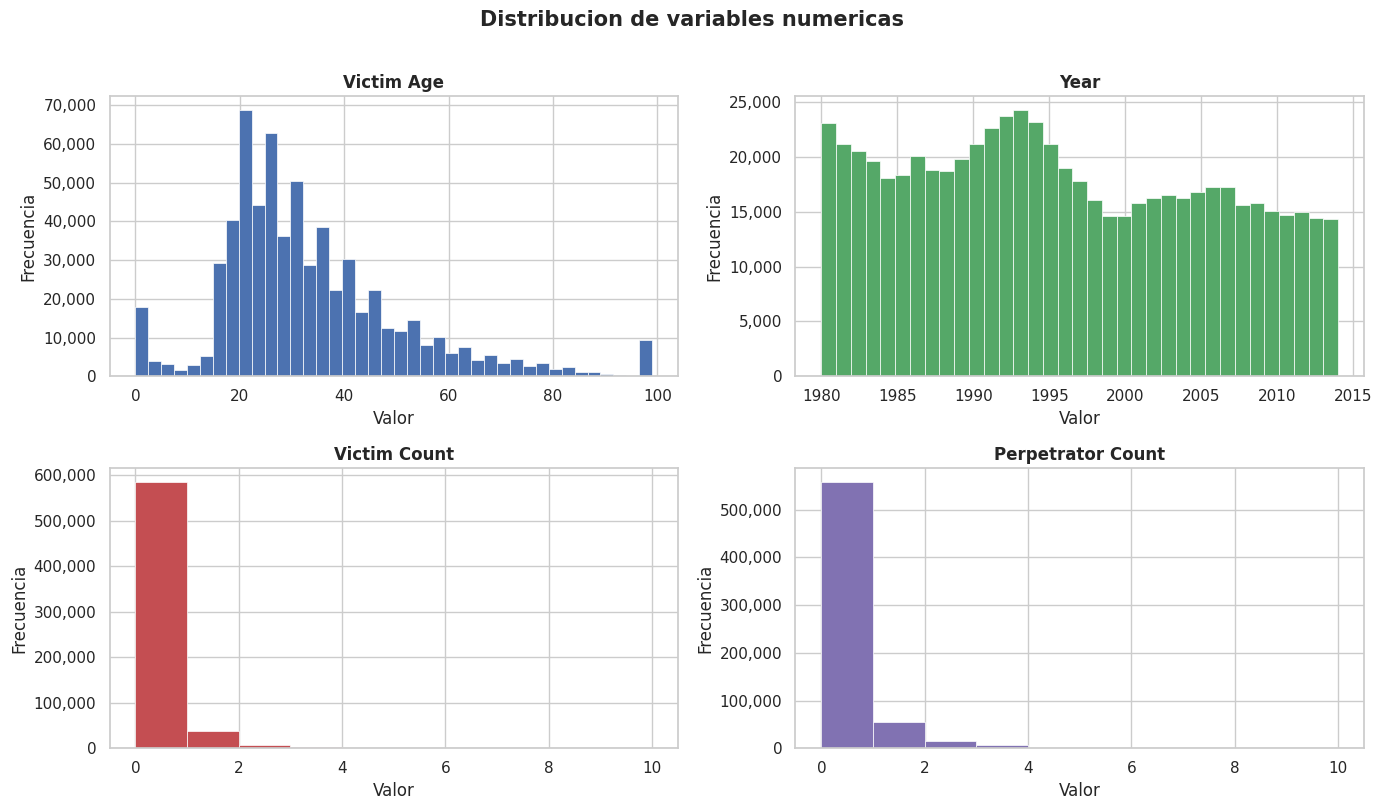

In [ ]:
import warnings
warnings.filterwarnings("ignore")

numericas_plot = ["Victim Age", "Year", "Victim Count", "Perpetrator Count"]
colores = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
# Definimos un número diferente de bins para cada gráfica
bins_por_variable = {
    "Victim Age": 40,
    "Year": 35,
    "Victim Count": 10,
    "Perpetrator Count": 10,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Distribucion de variables numericas", fontsize=15, fontweight="bold", y=1.01)

for ax, col, color in zip(axes.flatten(), numericas_plot, colores):
    datos = df[col].copy()
    if col == "Victim Age":
        datos = datos[datos < 100]
    ax.hist(datos.dropna(), bins=bins_por_variable[col], color=color, edgecolor="white", linewidth=0.5)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

### 3.2 Tendencia temporal de homicidios (1980-2014)

Serie de tiempo que muestra la evolucion anual del numero de casos registrados.

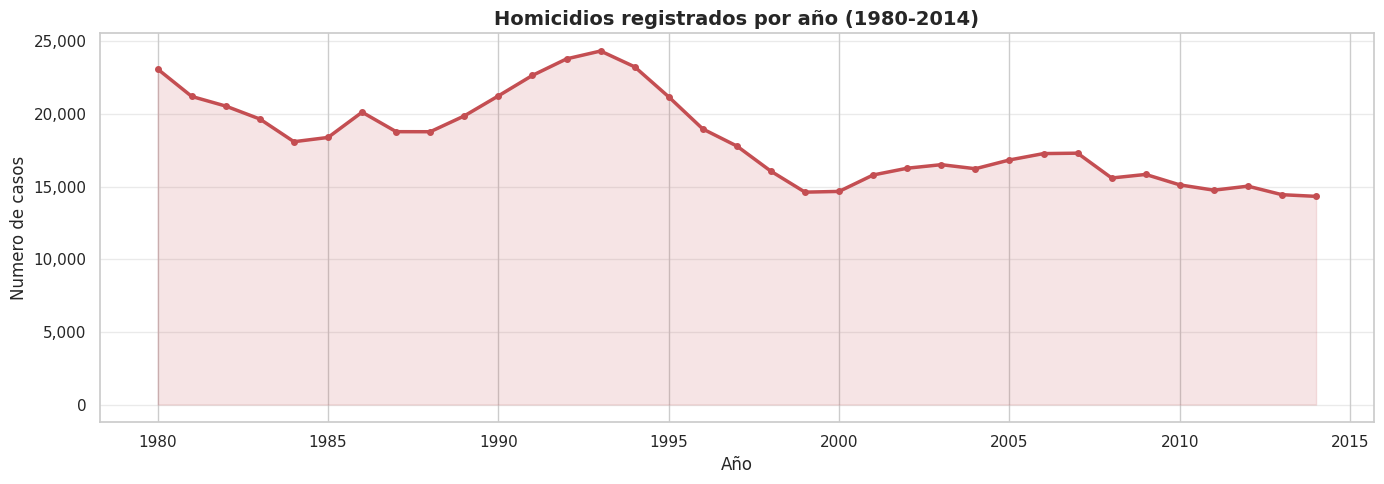

In [ ]:
homicidios_por_anio = df.groupby("Year").size().reset_index(name="Total")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(homicidios_por_anio["Year"], homicidios_por_anio["Total"],
        color="#C44E52", linewidth=2.5, marker="o", markersize=4)
ax.fill_between(homicidios_por_anio["Year"], homicidios_por_anio["Total"],
                alpha=0.15, color="#C44E52")
ax.set_title("Homicidios registrados por año (1980-2014)", fontsize=14, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Numero de casos")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

### 3.3 Distribucion geografica - Top 10 estados con mas homicidios

Grafico de barras horizontales para identificar la concentracion geografica de los casos.

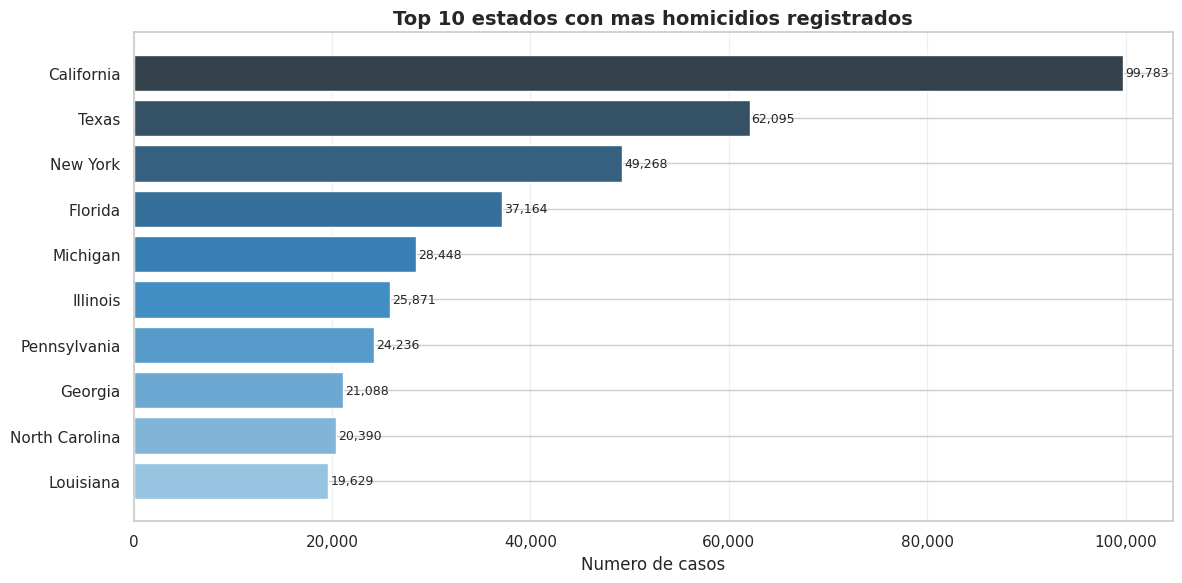

In [ ]:
top_estados = df["State"].value_counts().head(10).reset_index()
top_estados.columns = ["State", "Total"]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_estados["State"][::-1], top_estados["Total"][::-1],
               color=sns.color_palette("Blues_d", 10))
ax.set_title("Top 10 estados con mas homicidios registrados", fontsize=14, fontweight="bold")
ax.set_xlabel("Numero de casos")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in bars:
    width = bar.get_width()
    ax.text(width + 200, bar.get_y() + bar.get_height()/2,
            f"{int(width):,}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Distribucion demografica - Sexo de victimas y perpetradores

Comparacion lado a lado del genero, incluyendo registros "Unknown".

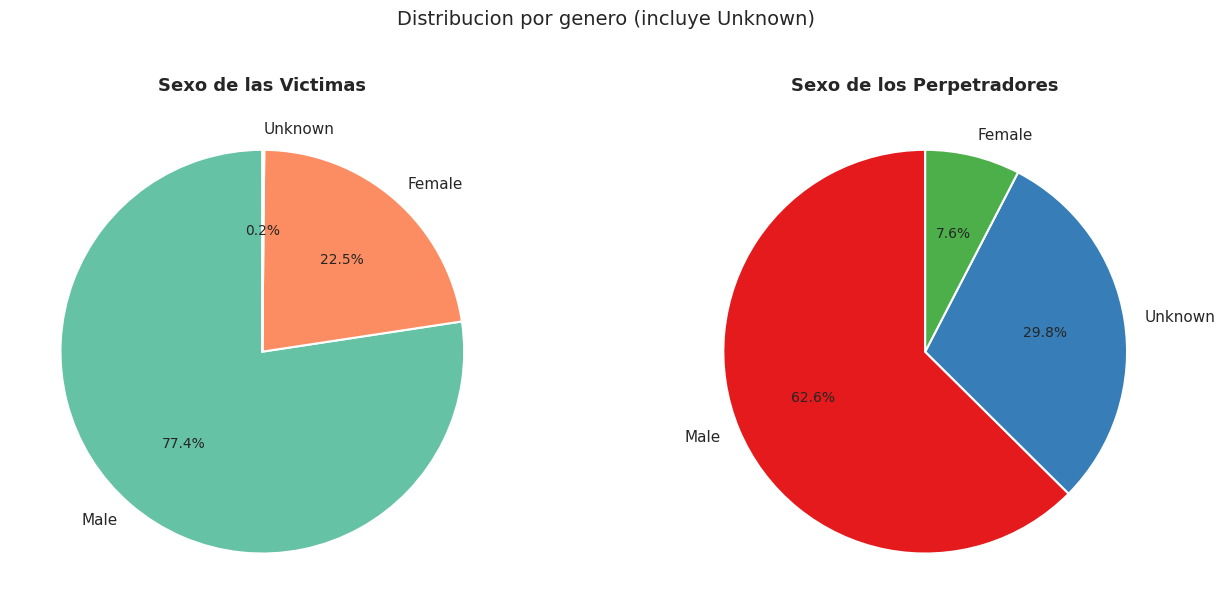

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pares = [
    ("Victim Sex",      "Sexo de las Victimas",      "Set2"),
    ("Perpetrator Sex", "Sexo de los Perpetradores", "Set1"),
]

for ax, (col, titulo, palette) in zip(axes, pares):
    conteo = df[col].value_counts()
    colores = sns.color_palette(palette, len(conteo))
    wedges, texts, autotexts = ax.pie(
        conteo, labels=conteo.index, autopct="%1.1f%%",
        colors=colores, startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5}
    )
    for at in autotexts:
        at.set_fontsize(10)
    ax.set_title(titulo, fontsize=13, fontweight="bold")

plt.suptitle("Distribucion por genero (incluye Unknown)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Distribucion por raza - Victimas vs Perpetradores

Grafico de barras agrupadas para comparar la composicion racial.

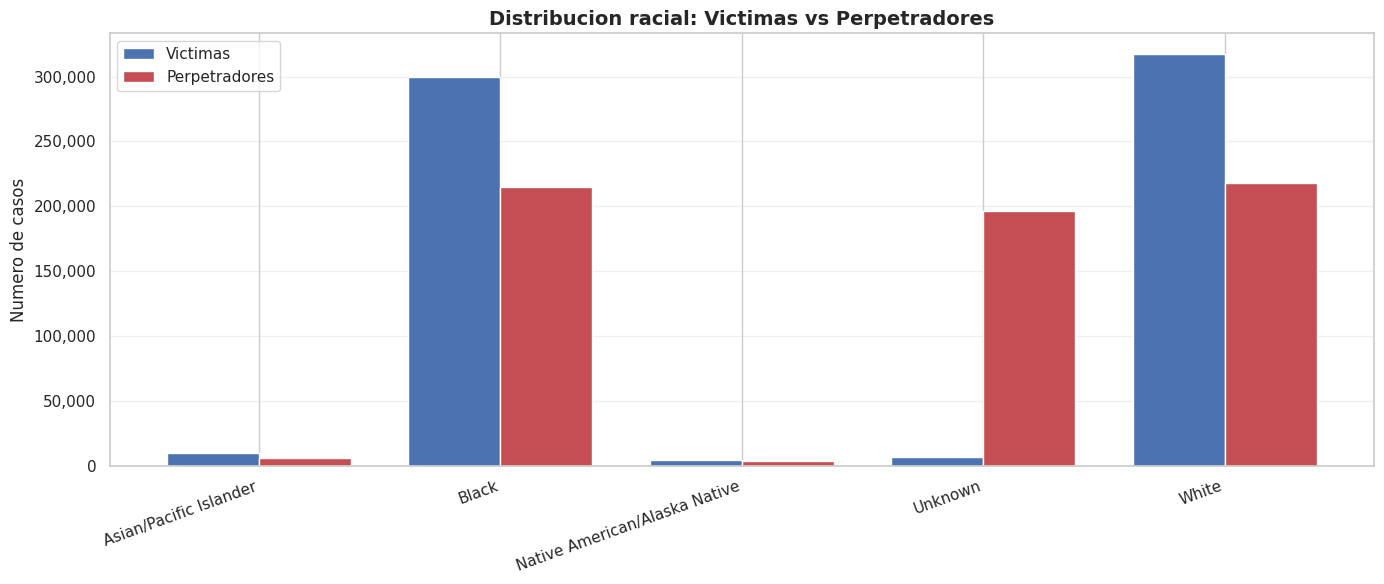

In [ ]:
import numpy as np

raza_victima = df["Victim Race"].value_counts()
raza_perp    = df["Perpetrator Race"].value_counts()

razas = sorted(set(raza_victima.index) | set(raza_perp.index))
v_vals = [raza_victima.get(r, 0) for r in razas]
p_vals = [raza_perp.get(r, 0)    for r in razas]

x = np.arange(len(razas))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, v_vals, width, label="Victimas",      color="#4C72B0", edgecolor="white")
ax.bar(x + width/2, p_vals, width, label="Perpetradores", color="#C44E52", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(razas, rotation=20, ha="right")
ax.set_title("Distribucion racial: Victimas vs Perpetradores", fontsize=14, fontweight="bold")
ax.set_ylabel("Numero de casos")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6 Armas mas utilizadas

Top 10 tipos de armas empleadas en los homicidios (excluye Unknown).

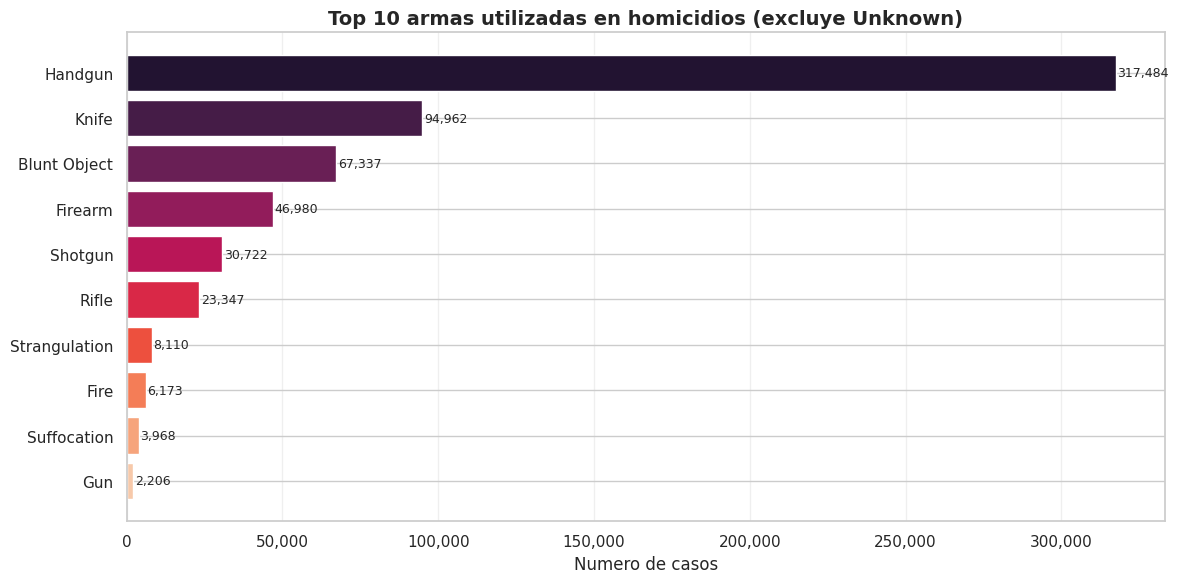

In [ ]:
armas = df[df["Weapon"] != "Unknown"]["Weapon"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(armas.index[::-1], armas.values[::-1],
               color=sns.color_palette("rocket_r", 10))
ax.set_title("Top 10 armas utilizadas en homicidios (excluye Unknown)", fontsize=14, fontweight="bold")
ax.set_xlabel("Numero de casos")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in bars:
    width = bar.get_width()
    ax.text(width + 500, bar.get_y() + bar.get_height()/2,
            f"{int(width):,}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.7 Dispersion - Edad victima vs Edad perpetrador

Explora si existe correlacion entre las edades de victima e imputado. Se filtran valores centinela (edad 0 y >= 100). Muestra de 5,000 casos.

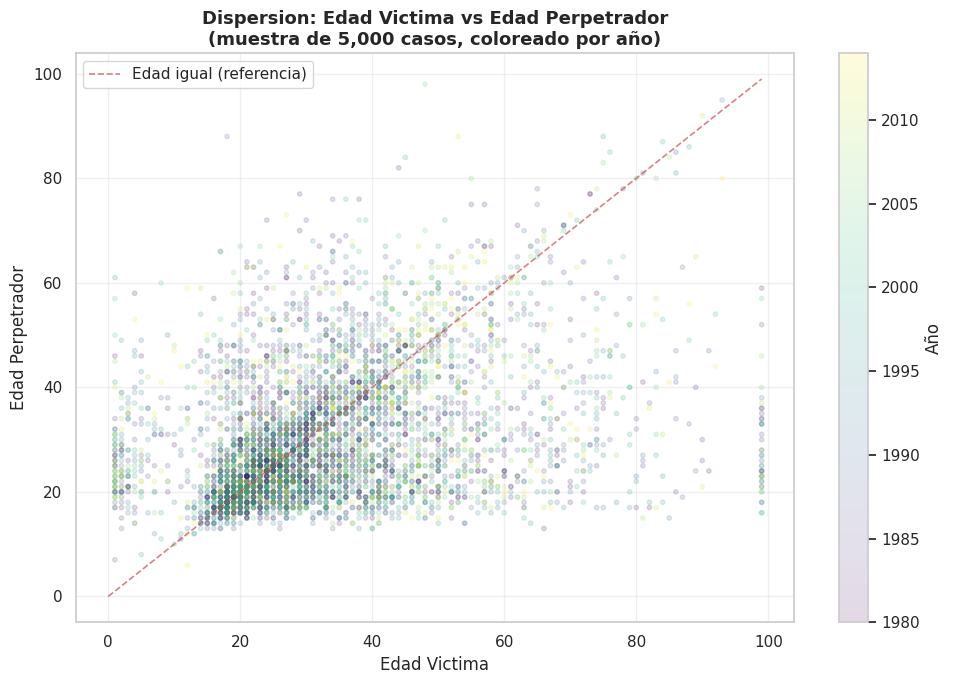

In [ ]:
df_scatter = df.copy()
df_scatter["Perpetrator Age"] = pd.to_numeric(df_scatter["Perpetrator Age"], errors="coerce")

mask = (
    df_scatter["Victim Age"].between(1, 99) &
    df_scatter["Perpetrator Age"].between(1, 99)
)
df_plot = df_scatter[mask].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df_plot["Victim Age"], df_plot["Perpetrator Age"],
    alpha=0.15, s=10, c=df_plot["Year"], cmap="viridis"
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Año")
ax.plot([0, 99], [0, 99], "r--", linewidth=1.2, alpha=0.7, label="Edad igual (referencia)")
ax.set_title("Dispersion: Edad Victima vs Edad Perpetrador\n(muestra de 5,000 casos, coloreado por año)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Edad Victima")
ax.set_ylabel("Edad Perpetrador")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.8 Tasa de resolucion de crimenes por año

Evolucion temporal del porcentaje de casos resueltos (Crime Solved = Yes).

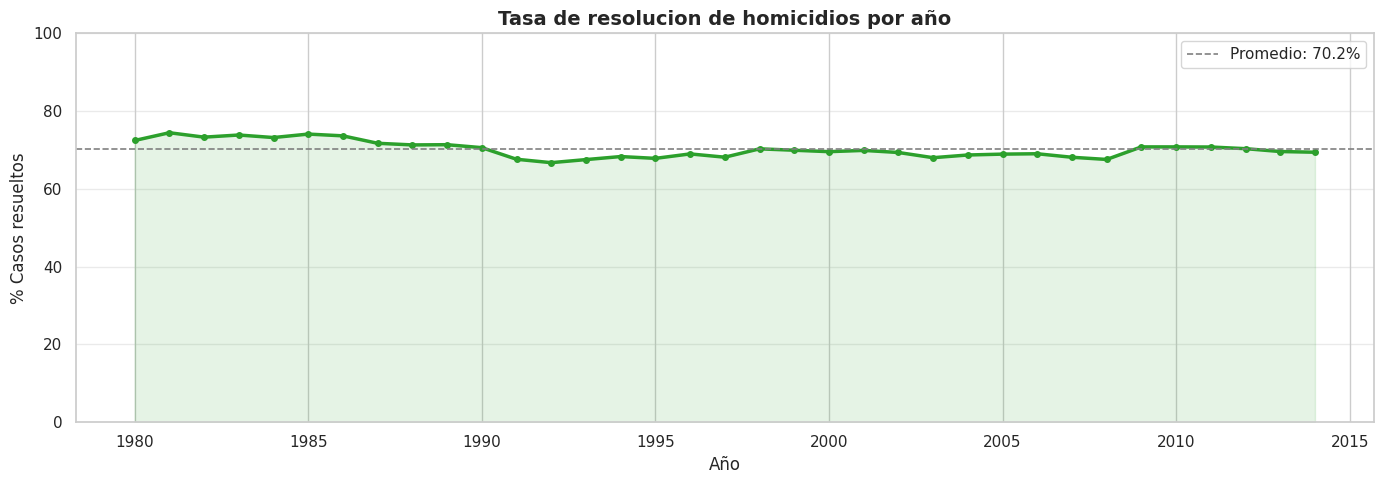

In [ ]:
resolucion = df.groupby("Year")["Crime Solved"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).reset_index(name="Tasa_Resolucion")

promedio = resolucion["Tasa_Resolucion"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(resolucion["Year"], resolucion["Tasa_Resolucion"],
        color="#2ca02c", linewidth=2.5, marker="o", markersize=4)
ax.fill_between(resolucion["Year"], resolucion["Tasa_Resolucion"],
                alpha=0.12, color="#2ca02c")
ax.axhline(y=promedio, color="gray", linestyle="--", linewidth=1.2,
           label=f"Promedio: {promedio:.1f}%")
ax.set_title("Tasa de resolucion de homicidios por año", fontsize=14, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("% Casos resueltos")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

### 3.9 Mapa de calor - Homicidios por Mes y Año

Heatmap para identificar patrones estacionales y temporales combinados.

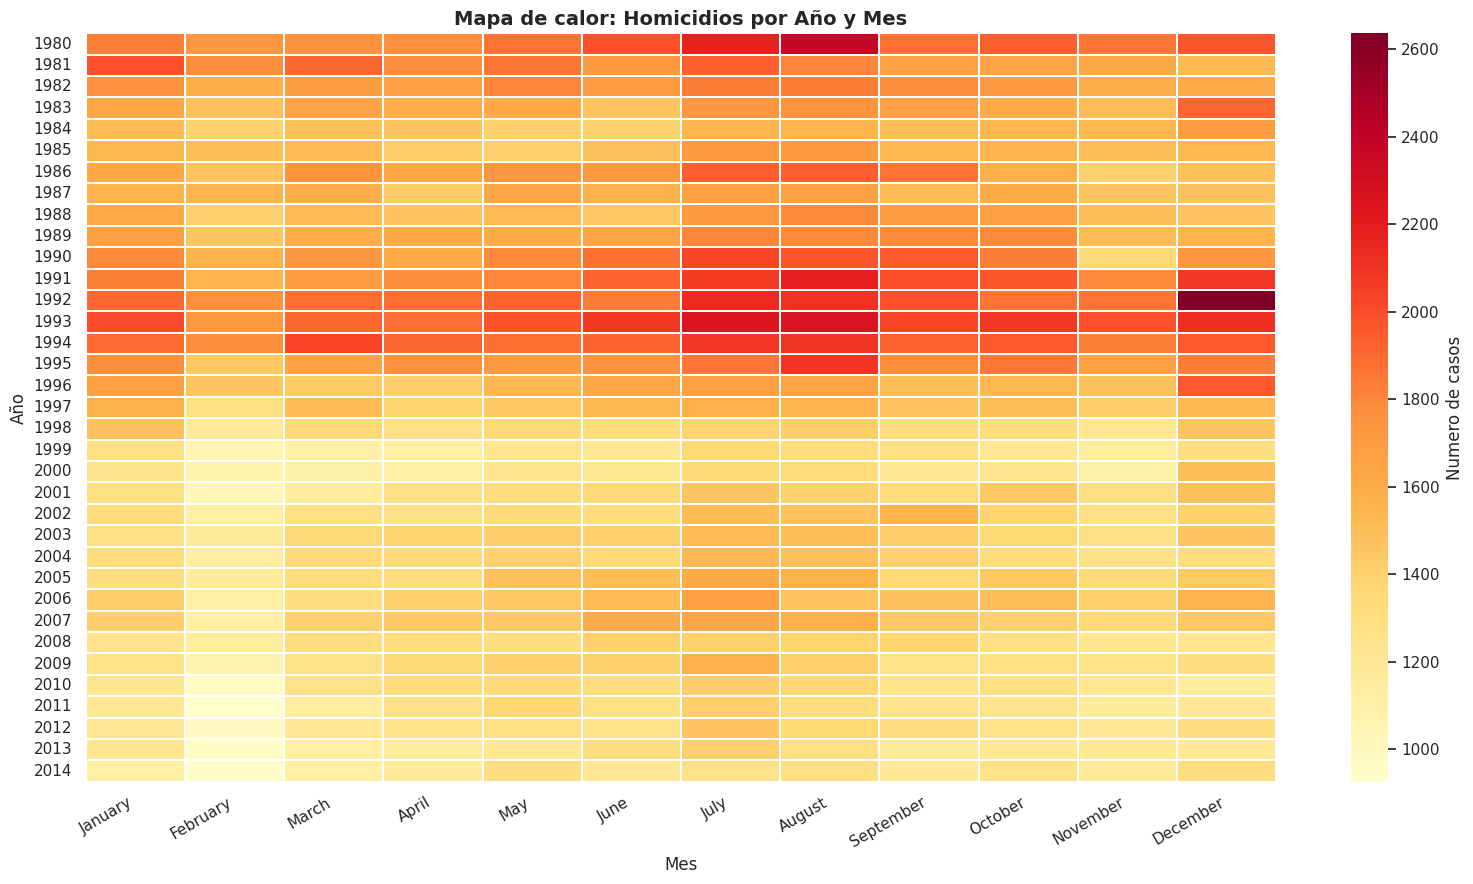

In [ ]:
orden_meses = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

pivot = df.groupby(["Year","Month"]).size().unstack(fill_value=0)
pivot = pivot[[m for m in orden_meses if m in pivot.columns]]

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            ax=ax, cbar_kws={"label": "Numero de casos"})
ax.set_title("Mapa de calor: Homicidios por Año y Mes", fontsize=14, fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 3.10 Relacion entre victima y perpetrador

Top 10 tipos de relacion para entender el contexto social de los homicidios (excluye Unknown).

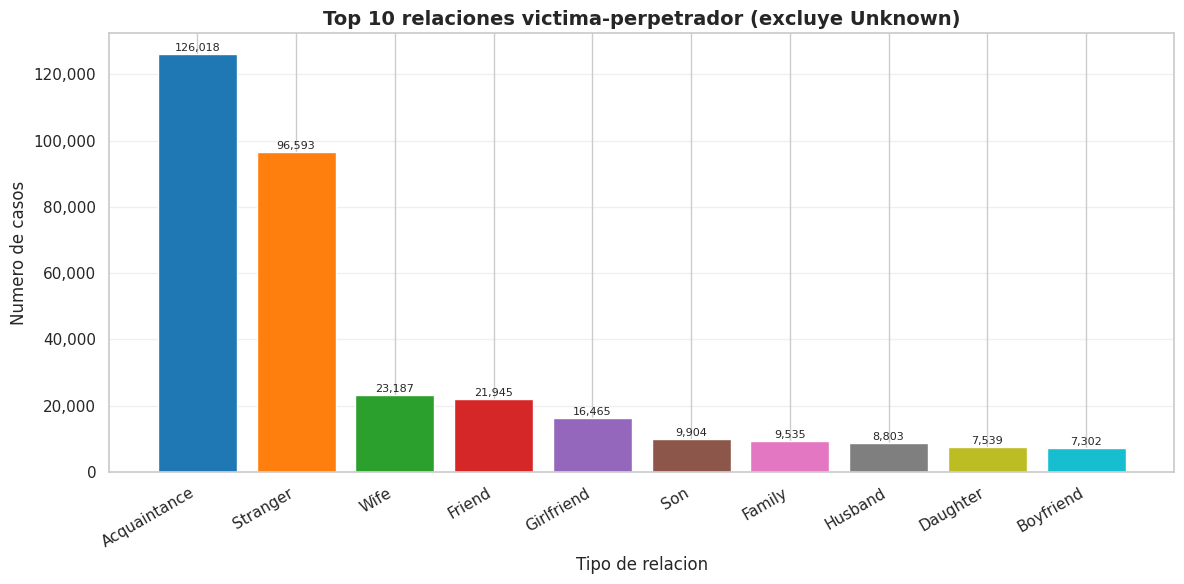

In [ ]:
relaciones = df[df["Relationship"] != "Unknown"]["Relationship"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(relaciones.index, relaciones.values,
              color=sns.color_palette("tab10", 10), edgecolor="white")
ax.set_title("Top 10 relaciones victima-perpetrador (excluye Unknown)", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de relacion")
ax.set_ylabel("Numero de casos")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=30, ha="right")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 300,
            f"{int(height):,}", ha="center", va="bottom", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.11 Análisis Multivariado

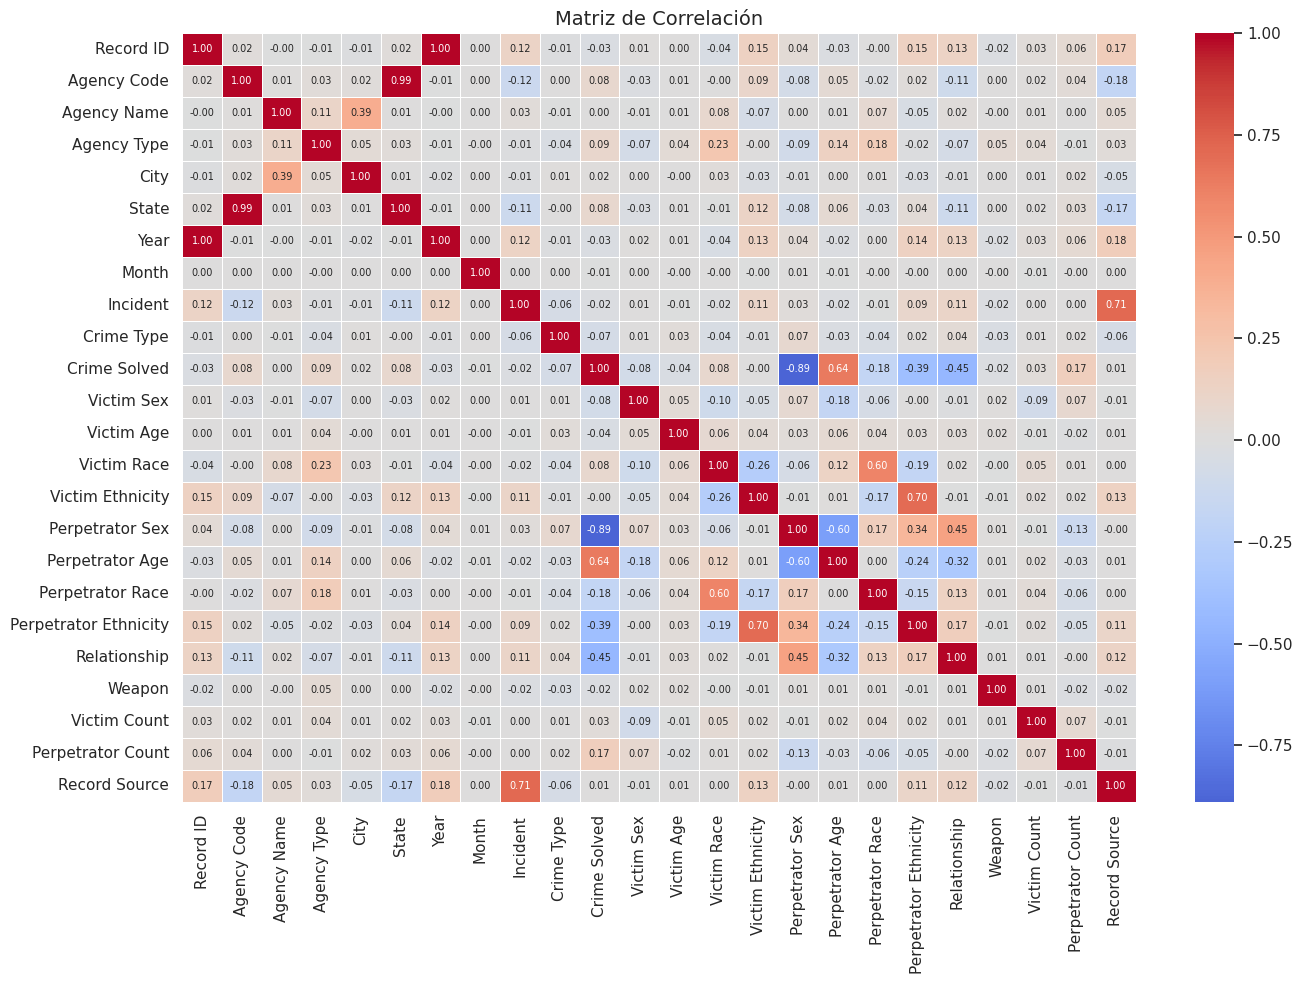

In [124]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

df_analysis = df.copy()

# Encodear temporalmente todas las columnas categóricas
le = LabelEncoder()
for col in df_analysis.select_dtypes(include='object').columns:
    df_analysis[col] = le.fit_transform(df_analysis[col].astype(str))

# Convertir todo a numérico, los que fallen, a NaN
df_analysis = df_analysis.apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(14, 10))
corr_matrix = df_analysis.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()

In [126]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Eliminar columnas con NaN para PCA
df_pca = df_analysis.dropna(axis=1)

# Escalar (obligatorio antes de PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# Aplicar PCA
pca = PCA()
pca.fit(X_scaled)

# Varianza explicada acumulada
explained_variance = np.cumsum(pca.explained_variance_ratio_) * 100

print("Varianza explicada por componente:")
for i, var in enumerate(pca.explained_variance_ratio_ * 100):
    print(f"  PC{i+1}: {var:.2f}%  (acumulado: {explained_variance[i]:.2f}%)")

Varianza explicada por componente:
  PC1: 13.05%  (acumulado: 13.05%)
  PC2: 9.67%  (acumulado: 22.72%)
  PC3: 9.12%  (acumulado: 31.84%)
  PC4: 7.86%  (acumulado: 39.71%)
  PC5: 6.29%  (acumulado: 46.00%)
  PC6: 5.70%  (acumulado: 51.69%)
  PC7: 5.33%  (acumulado: 57.02%)
  PC8: 4.52%  (acumulado: 61.55%)
  PC9: 4.42%  (acumulado: 65.97%)
  PC10: 4.29%  (acumulado: 70.27%)
  PC11: 4.16%  (acumulado: 74.43%)
  PC12: 4.09%  (acumulado: 78.52%)
  PC13: 3.79%  (acumulado: 82.31%)
  PC14: 3.56%  (acumulado: 85.87%)
  PC15: 3.28%  (acumulado: 89.15%)
  PC16: 2.64%  (acumulado: 91.79%)
  PC17: 2.48%  (acumulado: 94.28%)
  PC18: 1.80%  (acumulado: 96.07%)
  PC19: 1.55%  (acumulado: 97.62%)
  PC20: 1.18%  (acumulado: 98.80%)
  PC21: 0.77%  (acumulado: 99.57%)
  PC22: 0.40%  (acumulado: 99.97%)
  PC23: 0.02%  (acumulado: 99.99%)
  PC24: 0.01%  (acumulado: 100.00%)


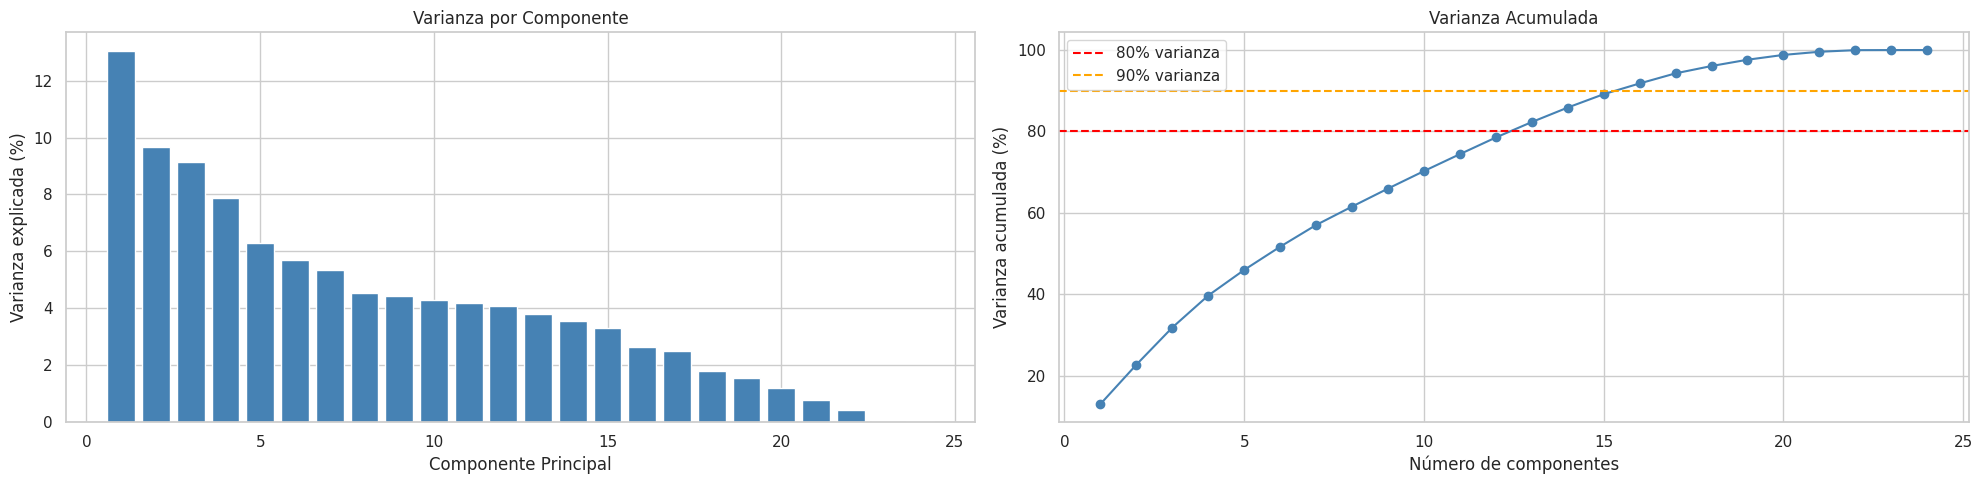

In [128]:
plt.figure(figsize=(20, 5))

# Varianza por componentes
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_ * 100, color='steelblue')
plt.xlabel('Componente Principal')
plt.ylabel('Varianza explicada (%)')
plt.title('Varianza por Componente')

# Varianza acumulada
plt.subplot(1, 2, 2)
plt.plot(range(1, len(explained_variance) + 1),
         explained_variance, marker='o', color='steelblue')
plt.axhline(y=80, color='red', linestyle='--', label='80% varianza')
plt.axhline(y=90, color='orange', linestyle='--', label='90% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada (%)')
plt.title('Varianza Acumulada')
plt.legend()

plt.tight_layout()
plt.show()

## <span style="color:Black;"><strong>4. Interpretaciones iniciales</strong></span>

En el análisis univariado se estudiaron distribuciones individuales, frecuencias y comportamiento estadístico de variables numéricas y categóricas. Posteriormente, mediante análisis bivariado y multivariado, se evaluaron relaciones entre variables sociales, geográficas y demográficas asociadas a los homicidios.

También se desarrollaron visualizaciones estadísticas que permitieron identificar tendencias temporales, concentración geográfica de homicidios, relaciones entre víctimas y perpetradores y patrones asociados al uso de armas.

<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b>¿Qué tendencias o patrones básicos se observan?</b>
</div>

Basado en el análisis exploratorio del dataset de homicidios en Estados Unidos, se identifican los siguientes patrones fundamentales:

- **Concentración geográfica**: California y Texas concentran aproximadamente el 26% del total de homicidios (16% y 10% respectivamente), sugiriendo que la violencia homicida está altamente localizada en determinadas regiones.

- **Vulnerabilidad etaria definida**: La mayor parte de las víctimas registran edades entre 19 y 39 años, configurando un rango etario identificable.

- **Patrón de género en victimización**: El 77% de las víctimas son hombres, mientras que el 63% de los victimarios identificados también son hombres.

- **Asimetría en la identificación de victimarios**: No existe una inclinación clara respecto a factores específicos de los victimarios más allá del género masculino predominante. Esta limitación en la caracterización del perfil del agresor dificulta la formulación de hipótesis sobre motivaciones, contextos sociales o factores de riesgo del perpetrador.

---

<div style="background-color:#E8F5E9; padding:10px; border-radius:8px;">
<b>¿Qué limitaciones tiene la base de datos?</b>
</div>

La base de datos presenta varias limitaciones metodológicas importantes que deben considerarse en análisis posteriores:

1. **Sesgos de cobertura geográfica**: La sobrerrepresentación de estados como California y Texas puede deberse a diferencias en sistemas de reporte, disponibilidad de datos históricos o variaciones en protocolos de registro entre jurisdicciones. Esto limita la generalización de hallazgos a nivel nacional.

2. **Información incompleta sobre victimarios**: El análisis revela que hay una caracterización limitada del perfil del victimario más allá del género. Faltan variables contextuales sobre motivación, antecedentes criminales o relación con la víctima.

3. **Sesgo potencial en casos resueltos**: La variable "Crime Solved" puede estar correlacionada con características demográficas de víctimas (posible sesgo).

4. **Falta de contexto socioeconómico**: La base de datos no incluye indicadores de pobreza, desempleo, densidad poblacional, acceso a servicios o variables socioeconómicas que puedan explicar la concentración geográfica observada.

---

<div style="background-color:#FFF9C4; padding:10px; border-radius:8px;">
<b>¿Qué hipótesis iniciales podrían plantearse para análisis posteriores?</b>
</div>

Con base en los patrones observados, se proponen las siguientes hipótesis para investigaciones futuras:

**Hipótesis geográficas:**
- La concentración de homicidios en California y Texas está asociada a factores estructurales (densidad poblacional, desigualdad económica) más que a factores coyunturales, lo que requeriría análisis comparativos entre estados.

**Hipótesis demográficas:**
- El patrón intra-género (hombres victimizando hombres en 63% de casos) está vinculado a dinámicas de violencia relacionada con conflictos de poder, territorios u organizaciones específicas, diferenciándose de otras formas de violencia interpersonal.
- El rango etario 19-39 años representa la población económicamente activa y potencialmente involucrada en dinámicas de conflicto (laborales, sociales, criminales) que elevan el riesgo de victimización.
- Las características demográficas de víctimas y perpetradores pueden estar correlacionadas (proximidad geográfica, grupo racial/étnico similar), sugiriendo homicidios comunitarios o criminalidad localizada.


---

<div style="background-color:#FFE0E0; padding:10px; border-radius:8px;">
<b>Alertas de calidad de datos identificadas en el analisis exploratorio</b>
</div>

Durante la revision del dataset se identificaron las siguientes alertas que deben considerarse al interpretar cualquier resultado:

**Alerta 1 - Valores faltantes enmascarados como "Unknown"**  
El reporte `Series([], dtype: int64)` en el conteo de nulos es engañoso. El dataset no usa `NaN` para datos faltantes sino el string `"Unknown"`, que Pandas interpreta como valor valido. Esto afecta especialmente las columnas del perpetrador (`Perpetrator Race`, `Perpetrator Sex`, `Relationship`, `Weapon`), consistente con el volumen de crimenes no resueltos.

**Alerta 2 - `Perpetrator Age` con tipo mixto (object)**  
La columna `Perpetrator Age` mezcla strings como `"Unknown"` y valores numericos, por eso Pandas la carga como `object` y es clasificada como categorica. Cualquier operacion aritmetica requiere conversion previa.

**Alerta 3 - Valores centinela en edades**  
`Victim Age` tiene un maximo de 998 y `Perpetrator Age` registra valores de 0,  ambos códigos de datos desconocidos y no edades reales. Además, tienen 191 y 101 valores únicos respectivamente. Estos valores contaminan el promedio de 35 años reportado; al filtrarlos (rango 1-99) el perfil etario real de las victimas cambia ligeramente.

**Alerta 4 - `Incident` con valores hasta 999**  
El valor 999 en `Incident` es tipico marcador de codigo de error en registros administrativos del FBI. No debe interpretarse como una variable continua sin validacion previa de su significado real.

**Alerta 5 - `Victim Count` y `Perpetrator Count` con mayoria de ceros**  
El 75% de los registros tiene 0 en ambas columnas, también se interpretan como códigos de datos desconocidos.

**Alerta 6 - Porcentajes de género calculados sobre universo completo**  
Las cifras "77% de victimas son hombres" y "63% de victimarios son hombres" incluyen en el denominador los registros `Unknown`. Al excluirlos, la proporcion de perpetradores masculinos identificados seria notablemente mayor, cambiando la magnitud de la disparidad reportada.

---

<div style="background-color:#FFE0E0; padding:10px; border-radius:8px;">
<b>Resultados del análisis multivariado</b>
</div>

En este caso se encontraron correlaciones bastante altas.

*   Agency Code y State tienen una correlación de 0.99. Son prácticamente lo mismo, por lo que se debe considerar eliminar alguna de las dos si se va a modelar.
*   Record ID tiene una correlación de 1 con Year e Incident. Esto tiene mucho sentido, ya que estas variables describen una secuencia. Record, Year e Incident son secuenciales, por lo que están fuertemente relacionadas. Sería preferible eliminar Record ID ya que no brinda mucha información.

Crime Solved tiene correlación con varias variables como Perpetrator Age, Perpetrator Age y Relationship. Sin embargo, no se puede concluir que las variables tengan o no que ver con la resolución del caso, sino al contrario. Si el caso está resuelto, hay menos información faltante.

Otra relación identificada fue la raza y la étnia entre la víctima y el victimario. Esto podría sugerir que los crímenes suelen ser cometidos entre comunidades cercanas.

**PCA**

El PC1 solo explica aproximadamente el 13% de la varianza, y se aprecia que en general ningún componente domina, lo que confirma que el dataset es complejo y multidimensional, no puede describirse con solo unos pocos componentes.
Se necesitan al menos unos 13 componentes para superar el 80% y 16 para superar el 90% de varianza explicada.

Esto indica que la información está distribuida entre muchas variables y no tiene una estructura simple.

# <span style="color:Black;"><strong>Fase 2: Preparación de Datos</strong></span>

Para continuar con el análisis, se decidió tener en cuenta únicamente los crímenes resueltos, con el motivo de que en los crímenes no resueltos hay muchos datos que no se conocen o que son inconsistentes.

Al hacer este filtro, estamos trabajando con datos más completos y consistentes, facilitando el análisis y la comprensión de la información que nos dejan estos datos.

<b>Filtro Crime Solved = True</b>

<ul>
<li><strong>Dataset Original:</strong> 638,454 registros</li>
<li><strong>Dataset Filtrado:</strong> 448,172 registros (70.2%)</li>
<li><strong>Eliminados:</strong> 190,282 registros (29.8% - casos no resueltos)</li>
</ul>

Cuando Crime Solved = False, los atributos del perpetrador (Perpetrator Sex, Age, Race, Ethnicity) contienen información no confiable o ausente ("Unknown", "Undetermined", valores centinela 0 y 99). Esto introduce ruido y sesgos.

Es mejor trabajar únicamente con Crime Solved = True, donde existe mayor certeza de información sobre perpetrador.

<b>Reducción de datos con la información de [OJJDP](https://https://ojjdp.ojp.gov/statistical-briefing-book/data-analysis-tools/ezashr/methods)</b>

<ul>
<li><strong>Weapon Used</strong> → 4 categorías
  <ul>
    <li>Firearm, Knife, Blunt Object, Other</li>
  </ul>
</li>
<li><strong>Relationship</strong> → 4 categorías
  <ul>
    <li>Family, Acquaintance, Stranger, Unknown</li>
  </ul>
</li>
</ul>

<b>Referencias:</b>
- OJJDP Statistical Briefing Book - Methods: <a href="https://ojjdp.ojp.gov/statistical-briefing-book/data-analysis-tools/ezashr/methods" target="_blank">Data Reduction</a>
- Metodología: Filtrar por completitud de datos para análisis de calidad superior

## <span style="color:Black;"><strong>5. Crime Solved = True</strong></span>

In [ ]:
# Contar registros ANTES y DESPUÉS del filtro por casos resueltos
n_total = len(df)
n_solved = (df['Crime Solved'] == 'Yes').sum()
pct_reduccion = ((n_total - n_solved) / n_total) * 100

print("PREPARACIÓN: Cálculo de métricas para Fase 2")
print(f"\n Registros totales: {n_total:,}")

n_unsolved = n_total - n_solved
print(f"   • Crime Solved = Yes: {n_solved:,} ({(n_solved/n_total*100):.2f}%)")
print(f"   • Crime Solved = No: {n_unsolved:,} ({(n_unsolved/n_total*100):.2f}%)")

# Crear dataset filtrado
df_solved = df[df['Crime Solved'] == 'Yes'].copy()

PREPARACIÓN: Cálculo de métricas para Fase 2

 Registros totales: 638,454
   • Crime Solved = Yes: 448,172 (70.20%)
   • Crime Solved = No: 190,282 (29.80%)


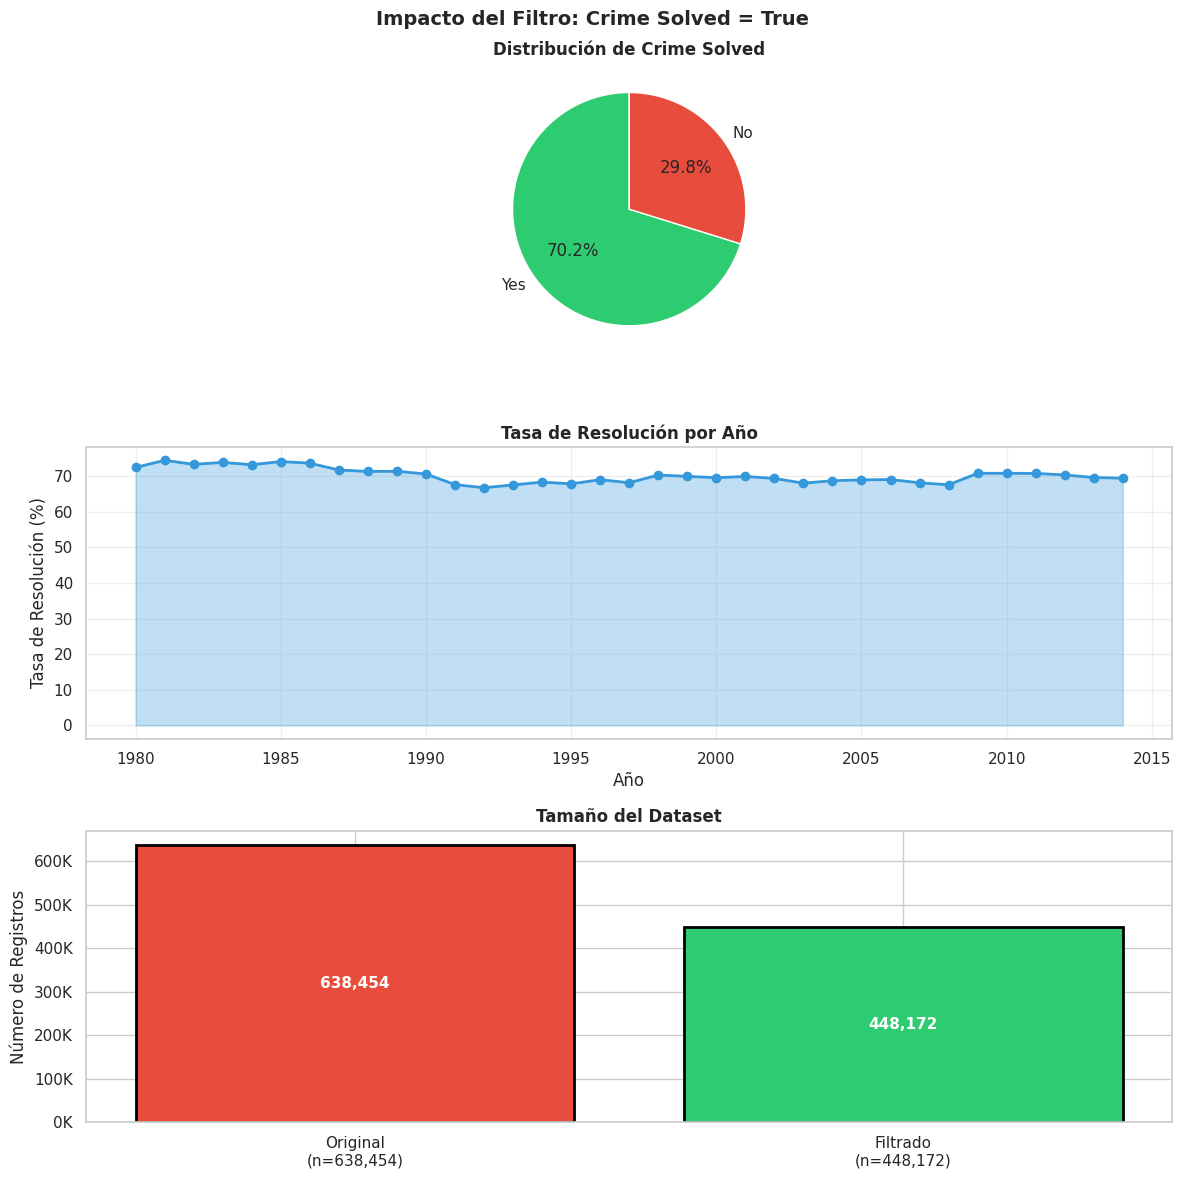

In [ ]:
# Visualización del impacto
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, figsize=(12, 12))
fig.suptitle('Impacto del Filtro: Crime Solved = True', fontsize=14, fontweight='bold')

# Gráfico 1: Distribución Crime Solved
ax1 = axes[0]
crime_data = df['Crime Solved'].value_counts()
colors = ['#2ecc71', '#e74c3c']
ax1.pie(crime_data.values, labels=crime_data.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Distribución de Crime Solved', fontweight='bold')

# Gráfico 2: Tasa de resolución por año
ax2 = axes[1]
años_resolucion = df.groupby('Year').apply(
    lambda x: (x['Crime Solved'] == 'Yes').sum() / len(x) * 100
)
ax2.plot(años_resolucion.index, años_resolucion.values, marker='o', linewidth=2, color='#3498db')
ax2.fill_between(años_resolucion.index, años_resolucion.values, alpha=0.3, color='#3498db')
ax2.set_title('Tasa de Resolución por Año', fontweight='bold')
ax2.set_xlabel('Año')
ax2.set_ylabel('Tasa de Resolución (%)')
ax2.grid(alpha=0.3)

# Gráfico 3: Reducción de memoria
ax3 = axes[2]
datasets = ['Original\n(n={:,})'.format(n_total), 'Filtrado\n(n={:,})'.format(n_solved)]
sizes = [n_total, n_solved]
colors_mem = ['#e74c3c', '#2ecc71']
bars = ax3.bar(datasets, sizes, color=colors_mem, edgecolor='black', linewidth=2)
ax3.set_title('Tamaño del Dataset', fontweight='bold')
ax3.set_ylabel('Número de Registros')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height/2, f'{size:,}',
             ha='center', va='center', fontweight='bold', fontsize=11, color='white')

plt.tight_layout()
plt.show()

---

## <span style="color:Black;"><strong>6. OJJDP Data Reduction</strong></span>

<div style="background-color:#E0F0FF; padding:15px; border-radius:8px;">
<b>Referencia Oficial:</b> OJJDP Statistical Briefing Book - Methods
<br><a href="https://ojjdp.ojp.gov/statistical-briefing-book/data-analysis-tools/ezashr/methods" target="_blank">https://ojjdp.ojp.gov/statistical-briefing-book/data-analysis-tools/ezashr/methods</a>

<b>Objetivo:</b> Aplicar estrategia de reducción de cardinalidad para mejorar interpretabilidad y evitar curse of dimensionality

<b>Variables a agrupar:</b>
1. <b>Weapon Used</b>: 35 categorías → 5 grupos (Firearm, Knife, Blunt Object, Personal, Other)
2. <b>Victim-Offender Relationship</b>: 15+ categorías → 4 grupos (Family, Acquaintance, Stranger, Unknown)

<b>Ventajas:</b>
- Reduce dimensionalidad sin perder información crucial
- Alineado con metodología estándar internacional (OJJDP)
- Mejora interpretabilidad de resultados
- Facilita análisis comparativos posteriores
</div>

In [ ]:
# Verificar nombres de columnas
print("Columnas disponibles en df_solved:")
print(df_solved.columns.tolist())

Columnas disponibles en df_solved:
['Record ID', 'Agency Code', 'Agency Name', 'Agency Type', 'City', 'State', 'Year', 'Month', 'Incident', 'Crime Type', 'Crime Solved', 'Victim Sex', 'Victim Age', 'Victim Race', 'Victim Ethnicity', 'Perpetrator Sex', 'Perpetrator Age', 'Perpetrator Race', 'Perpetrator Ethnicity', 'Relationship', 'Weapon', 'Victim Count', 'Perpetrator Count', 'Record Source']


### <span style="color:Black;"><strong>6.1 Armas usadas</strong></span>

In [ ]:
# Definición de mappings con OJJDP - Armas usadas

print("\nReducción de armas usadas")

# Valores únicos actuales
print("\nValores únicos ANTES del grouping:")
weapon_counts = df_solved['Weapon'].value_counts()
print(f"Total de categorías: {len(weapon_counts)}")
print(weapon_counts.head(16))

# Definir mapping OJJDP para Weapon
weapon_mapping = {
    # Firearm category
    'Firearm': 'Firearm',
    'Gun': 'Firearm',
    'Handgun': 'Firearm',
    'Rifle': 'Firearm',
    'Shotgun': 'Firearm',

    # Knife y Blunt Object no requieren mapeo, son únicas.
    'Knife': 'Knife',
    'Blunt Object': 'Blunt Object',

    # Other category
    'Drowning': 'Other',
    'Drugs': 'Other',
    'Explosives': 'Other',
    'Fall': 'Other',
    'Fire': 'Other',
    'Poison': 'Other',
    'Strangulation': 'Other',
    'Suffocation': 'Other',
    'Unknown': 'Other',
}

# Categoría default para unmapped values
DEFAULT_WEAPON_CATEGORY = 'Other'

# Normalizar valores de Weapon para mapping
def normalize_weapon(val):
    if pd.isna(val) or val == '':
        return 'Unknown'
    val_str = str(val).strip().title()
    # Buscar match exacto normalizado
    for key, category in weapon_mapping.items():
        if val_str.lower() == key.lower():
            return category
    # Si no hay match exacto, retornar Other
    return DEFAULT_WEAPON_CATEGORY

# Crear nueva columna con grouping OJJDP
df_solved['Weapon_OJJDP'] = df_solved['Weapon'].apply(normalize_weapon)

# Estadísticas del nuevo grouping
print("\nValores DESPUÉS del grouping OJJDP:")
weapon_counts_ojjdp = df_solved['Weapon_OJJDP'].value_counts()
print(f"Total de categorías: {len(weapon_counts_ojjdp)}")
print(f"\nDistribución:")
for cat, count in weapon_counts_ojjdp.items():
    pct = (count / len(df_solved)) * 100
    print(f"   {cat:<20} : {count:>8,} ({pct:>5.2f}%)")


Reducción de armas usadas

Valores únicos ANTES del grouping:
Total de categorías: 16
Weapon
Handgun          216938
Knife             74758
Blunt Object      51504
Shotgun           26040
Firearm           24402
Rifle             19946
Unknown           18409
Strangulation      4409
Fire               4139
Suffocation        2978
Drugs              1396
Gun                1324
Drowning            999
Explosives          388
Poison              376
Fall                166
Name: count, dtype: int64

Valores DESPUÉS del grouping OJJDP:
Total de categorías: 4

Distribución:
   Firearm              :  288,650 (64.41%)
   Knife                :   74,758 (16.68%)
   Blunt Object         :   51,504 (11.49%)
   Other                :   33,260 ( 7.42%)


### <span style="color:Black;"><strong>6.2 Relación víctima/victimario</strong></span>

In [ ]:
# Definición de mappings con OJJDP - Relaciones entre víctima y victimario
print("\nReducción entre relación víctima/victimario")

# Valores únicos actuales
print("\nValores únicos ANTES del grouping:")
rel_counts = df_solved['Relationship'].value_counts()
print(f"Total de categorías: {len(rel_counts)}")
print("\nTodas las categorías:")
for cat, count in rel_counts.items():
    pct = (count / len(df_solved)) * 100
    print(f"   {cat:<30} : {count:>8,} ({pct:>5.2f}%)")

# Definir mapping OJJDP para Relationship
relationship_mapping = {
    # Family category
    'Brother': 'Family',
    'Common-Law Husband': 'Family',
    'Common-Law Wife': 'Family',
    'Daughter': 'Family',
    'Family': 'Family',
    'Father': 'Family',
    'Husband': 'Family',
    'In-Law': 'Family',
    'Mother': 'Family',
    'Sister': 'Family',
    'Son': 'Family',
    'Stepdaughter': 'Family',
    'Stepfather': 'Family',
    'Stepmother': 'Family',
    'Stepson': 'Family',
    'Wife': 'Family',

    # Acquaintance category
    'Acquaintance': 'Acquaintance',
    'Boyfriend': 'Acquaintance',
    'Boyfriend/Girlfriend': 'Acquaintance',
    'Employee': 'Acquaintance',
    'Employer': 'Acquaintance',
    'Ex-Husband': 'Acquaintance',
    'Ex-Wife': 'Acquaintance',
    'Friend': 'Acquaintance',
    'Girlfriend': 'Acquaintance',
    'Neighbor': 'Acquaintance',

    # Stranger y Unknown no requieren mapeo, son únicas.
    'Stranger': 'Stranger',
    'Unknown': 'Unknown',
}

DEFAULT_RELATIONSHIP_CATEGORY = 'Unknown'

# Normalizar valores de Relationship para mapping
def normalize_relationship(val):
    if pd.isna(val) or val == '':
        return 'Unknown'
    val_str = str(val).strip()
    # Buscar match exacto
    for key, category in relationship_mapping.items():
        if val_str.lower() == key.lower():
            return category
    # Si no hay match exacto, retornar Unknown
    return DEFAULT_RELATIONSHIP_CATEGORY

# Crear nueva columna con grouping OJJDP
df_solved['Relationship_OJJDP'] = df_solved['Relationship'].apply(normalize_relationship)

# Estadísticas del nuevo grouping
print("\nValores DESPUÉS del grouping OJJDP:")
rel_counts_ojjdp = df_solved['Relationship_OJJDP'].value_counts()
print(f"Total de categorías: {len(rel_counts_ojjdp)}")
print(f"\nDistribución:")
for cat, count in rel_counts_ojjdp.items():
    pct = (count / len(df_solved)) * 100
    print(f"   {cat:<20} : {count:>8,} ({pct:>5.2f}%)")


Reducción entre relación víctima/victimario

Valores únicos ANTES del grouping:
Total de categorías: 28

Todas las categorías:
   Acquaintance                   :  123,852 (27.63%)
   Unknown                        :   94,892 (21.17%)
   Stranger                       :   87,362 (19.49%)
   Wife                           :   23,142 ( 5.16%)
   Friend                         :   21,718 ( 4.85%)
   Girlfriend                     :   16,413 ( 3.66%)
   Son                            :    9,842 ( 2.20%)
   Family                         :    9,467 ( 2.11%)
   Husband                        :    8,777 ( 1.96%)
   Daughter                       :    7,487 ( 1.67%)
   Boyfriend                      :    7,288 ( 1.63%)
   Neighbor                       :    6,258 ( 1.40%)
   Brother                        :    5,496 ( 1.23%)
   Father                         :    4,353 ( 0.97%)
   Mother                         :    4,238 ( 0.95%)
   In-Law                         :    3,628 ( 0.81%)
   Commo

In [ ]:
# Reducción OJJDP

reduction_summary = pd.DataFrame({
    'Variable': ['Weapon Used', 'Relationship'],
    'Categorías_Antes': [len(weapon_counts), len(rel_counts)],
    'Categorías_Después': [len(weapon_counts_ojjdp), len(rel_counts_ojjdp)],
    'Reducción_%': [
        ((len(weapon_counts) - len(weapon_counts_ojjdp)) / len(weapon_counts) * 100),
        ((len(rel_counts) - len(rel_counts_ojjdp)) / len(rel_counts) * 100)
    ]
})

print("\nTABLA COMPARATIVA:")
print(reduction_summary.to_string(index=False))

print("Se agregan nuevas columnas con la reducción OJJDP:")
print(f"   • df_solved['Weapon_OJJDP']")
print(f"   • df_solved['Relationship_OJJDP']")
print(f"\nDataset actualizado: {df_solved.shape[0]:,} registros × {df_solved.shape[1]} variables")


TABLA COMPARATIVA:
    Variable  Categorías_Antes  Categorías_Después  Reducción_%
 Weapon Used                16                   4    75.000000
Relationship                28                   4    85.714286
Se agregan nuevas columnas con la reducción OJJDP:
   • df_solved['Weapon_OJJDP']
   • df_solved['Relationship_OJJDP']

Dataset actualizado: 448,172 registros × 26 variables


In [ ]:
# Estandarización - Eliminamos las columnas originales y mantenemos las reducciones con  OJJDP

print("\nAntes de los cambios:")
print(f"   Columnas: {df_solved.shape[1]}")

# Eliminar columnas originales
df_solved = df_solved.drop(columns=['Relationship', 'Weapon'])

# Renombrar columnas OJJDP a sus nombres originales (pero con datos agrupados)
df_solved = df_solved.rename(columns={
    'Weapon_OJJDP': 'Weapon',
    'Relationship_OJJDP': 'Relationship'
})

print("\nDESPUÉS DE CAMBIOS:")
print(f"   Columnas: {df_solved.shape[1]}")

print("\nNUEVAS DISTRIBUCIONES:")
print(f"\nWeapon (OJJDP):")
for cat, count in df_solved['Weapon'].value_counts().items():
    pct = (count / len(df_solved)) * 100
    print(f"      • {cat:<20} : {count:>8,} ({pct:>5.2f}%)")

print(f"\nRelationship (OJJDP):")
for cat, count in df_solved['Relationship'].value_counts().items():
    pct = (count / len(df_solved)) * 100
    print(f"      • {cat:<20} : {count:>8,} ({pct:>5.2f}%)")

print(f"\nDataset estandarizado: {df_solved.shape[0]:,} × {df_solved.shape[1]} variables")


Antes de los cambios:
   Columnas: 26

DESPUÉS DE CAMBIOS:
   Columnas: 24

NUEVAS DISTRIBUCIONES:

Weapon (OJJDP):
      • Firearm              :  288,650 (64.41%)
      • Knife                :   74,758 (16.68%)
      • Blunt Object         :   51,504 (11.49%)
      • Other                :   33,260 ( 7.42%)

Relationship (OJJDP):
      • Acquaintance         :  180,291 (40.23%)
      • Unknown              :   94,892 (21.17%)
      • Stranger             :   87,362 (19.49%)
      • Family               :   85,627 (19.11%)

Dataset estandarizado: 448,172 × 24 variables


## <span style="color:Black;"><strong>7. Reducción de Estados</strong></span>

In [ ]:
# Análisis de impacto del filtro Crime Solved en el % de resolución por Estado

# Análisis por estado
print(f"\nTOP 10 ESTADOS - TASA DE RESOLUCIÓN:")
top_estados = df.groupby('State').apply(
    lambda x: pd.Series({
        'Total': len(x),
        'Solved': (x['Crime Solved'] == 'Yes').sum(),
        'Tasa_%': ((x['Crime Solved'] == 'Yes').sum() / len(x) * 100)
    })
).sort_values('Tasa_%', ascending=False).head(51)
print(top_estados.to_string())


TOP 10 ESTADOS - TASA DE RESOLUCIÓN:
                        Total   Solved     Tasa_%
State                                            
North Dakota            308.0    287.0  93.181818
Montana                 601.0    557.0  92.678869
South Dakota            442.0    406.0  91.855204
South Carolina        11698.0  10618.0  90.767653
Idaho                  1150.0   1040.0  90.434783
Wyoming                 630.0    569.0  90.317460
West Virginia          3061.0   2743.0  89.611238
Maine                   869.0    777.0  89.413119
Vermont                 412.0    364.0  88.349515
Iowa                   1749.0   1524.0  87.135506
Utah                   2033.0   1748.0  85.981308
Tennessee             14930.0  12561.0  84.132619
Arkansas               6947.0   5842.0  84.093853
Mississippi            6546.0   5501.0  84.036053
New Hampshire           655.0    547.0  83.511450
Nebraska               1331.0   1110.0  83.395943
Wisconsin              6191.0   5144.0  83.088354
Oklahoma    

District of Columbia y Washington se cuentan por separado, cuando hacen referencia al mismo estado.

In [ ]:
# District of Columbia = Washington

print("\nReducción de Estados")

# Valores únicos actuales
print("\nValores únicos ANTES del grouping:")
state_counts = df_solved['State'].value_counts()
print(f"Total de categorías: {len(state_counts)}")
print("\nTodas las categorías:")
for cat, count in state_counts.items():
    pct = (count / len(df_solved)) * 100
    print(f"   {cat:<30} : {count:>8,} ({pct:>5.2f}%)")

# Definir mapping OJJDP para Relationship
state_mapping = {'District of Columbia': 'Washington'}
DEFAULT_STATE = 'Unknown'

# Normalizar valores de State para mapping
def normalize_state(val):
    if pd.isna(val) or val == '':
        return 'Unknown'
    val_str = str(val).strip()
    # Buscar match exacto
    for key, category in state_mapping.items():
        if val_str.lower() == key.lower():
            return category
    # Si no hay match exacto, retornar Unknown
    return val_str

# Reemplazar
df_solved['State'] = df_solved['State'].apply(normalize_state)

# Estadísticas del nuevo grouping
print("\nValores DESPUÉS de la reducción:")
state_reducted = df_solved['State'].value_counts()
print(f"Total de categorías: {len(state_reducted)}")
print(f"\nDistribución:")
for cat, count in state_reducted.items():
    pct = (count / len(df_solved)) * 100
    print(f"   {cat:<20} : {count:>8,} ({pct:>5.2f}%)")


Reducción de Estados

Valores únicos ANTES del grouping:
Total de categorías: 51

Todas las categorías:
   California                     :   63,414 (14.15%)
   Texas                          :   47,415 (10.58%)
   New York                       :   26,656 ( 5.95%)
   Florida                        :   26,517 ( 5.92%)
   Michigan                       :   19,014 ( 4.24%)
   Pennsylvania                   :   18,426 ( 4.11%)
   North Carolina                 :   16,354 ( 3.65%)
   Illinois                       :   15,845 ( 3.54%)
   Georgia                        :   15,240 ( 3.40%)
   Ohio                           :   13,729 ( 3.06%)
   Louisiana                      :   13,582 ( 3.03%)
   Tennessee                      :   12,561 ( 2.80%)
   Virginia                       :   12,217 ( 2.73%)
   South Carolina                 :   10,618 ( 2.37%)
   Maryland                       :   10,308 ( 2.30%)
   Missouri                       :    9,475 ( 2.11%)
   Arizona                     

## <span style="color:Black;"><strong>8. Validación y categorización de datos</strong></span>

Se va a dentificar y clasificar tipos de datos correctamente, así como identificar y mapear variables con "Unknown", datos desconocidos y atípicos.

In [ ]:
# Debemos convertir Perpetrator Age de tipo object a numérico, ya que se actualmente se toma como variable categórica y debería ser numérica

df_solved['Perpetrator Age'] = df_solved['Perpetrator Age'].astype(str).str.strip() # Quitamos los espacios para poder tener valores únicos que no se repitan, ejemplo: '0' y '  0', serían únicamente '0'.

In [ ]:
# Convertir a numeric (cualquier valor no convertible a NaN)
df_solved['Perpetrator Age'] = (pd.to_numeric(df_solved['Perpetrator Age'], errors='coerce').astype('int64'))

print(f"Perpetrator Age convertido a tipo: {df_solved['Perpetrator Age'].dtype}")
print(f"Valores numéricos: {df_solved['Perpetrator Age'].notna().sum():,}")
print(f"Valores faltantes (NaN): {df_solved['Perpetrator Age'].isna().sum():,}")
print(f"Rango: {df_solved['Perpetrator Age'].min():.0f} a {df_solved['Perpetrator Age'].max():.0f}")
print(f"Media: {df_solved['Perpetrator Age'].mean():.2f}, Mediana: {df_solved['Perpetrator Age'].median():.2f}")

# Mostrar distribución de valores anomalos
print(f"\n   Estadísticas por grupos etarios:")
print(f"   • Edad = 0: {(df_solved['Perpetrator Age'] == 0).sum():,} ({(df_solved['Perpetrator Age'] == 0).sum()/len(df_solved)*100:.2f}%)")
print(f"   • Edad 1-18: {((df_solved['Perpetrator Age'] >= 1) & (df_solved['Perpetrator Age'] <= 18)).sum():,}")
print(f"   • Edad 19-65: {((df_solved['Perpetrator Age'] >= 19) & (df_solved['Perpetrator Age'] <= 65)).sum():,}")
print(f"   • Edad > 65: {(df_solved['Perpetrator Age'] > 65).sum():,}")

Perpetrator Age convertido a tipo: int64
Valores numéricos: 448,172
Valores faltantes (NaN): 0
Rango: 0 a 99
Media: 28.90, Mediana: 26.00

   Estadísticas por grupos etarios:
   • Edad = 0: 26,700 (5.96%)
   • Edad 1-18: 52,707
   • Edad 19-65: 360,082
   • Edad > 65: 8,683


In [ ]:
# Tipología de datos - Clasificación inicial

# Obtener tipos de datos
tipos_datos = df_solved.dtypes.value_counts().sort_values(ascending=False)
print("\nDistribución de tipos de datos:")
for tipo, count in tipos_datos.items():
    print(f"  • {tipo}: {count} variables")

# Clasificar variables por tipo
numericas = df_solved.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df_solved.select_dtypes(include=['object']).columns.tolist()

print(f"\nVariables NUMÉRICAS ({len(numericas)}):")
for col in sorted(numericas):
    print(f"  • {col}")

print(f"\nVariables CATEGÓRICAS ({len(categoricas)}):")
for col in sorted(categoricas):
    print(f"  • {col}")


Distribución de tipos de datos:
  • object: 17 variables
  • int64: 7 variables

Variables NUMÉRICAS (7):
  • Incident
  • Perpetrator Age
  • Perpetrator Count
  • Record ID
  • Victim Age
  • Victim Count
  • Year

Variables CATEGÓRICAS (17):
  • Agency Code
  • Agency Name
  • Agency Type
  • City
  • Crime Solved
  • Crime Type
  • Month
  • Perpetrator Ethnicity
  • Perpetrator Race
  • Perpetrator Sex
  • Record Source
  • Relationship
  • State
  • Victim Ethnicity
  • Victim Race
  • Victim Sex
  • Weapon


In [ ]:
# Mapeo de MISSING DATA enmascarado como "Unknown"

print("3. DETECCIÓN DE MISSING DATA ENMASCARADO")

# Buscar "Unknown" en todas las variables categóricas
unknown_count = {}
for col in categoricas:
    unk_count = (df_solved[col] == "Unknown").sum()
    if unk_count > 0:
        unknown_count[col] = unk_count

# Ordenar por cantidad descendente
unknown_sorted = dict(sorted(unknown_count.items(), key=lambda x: x[1], reverse=True))

print(f"\nALERTA: Encontrados {len(unknown_sorted)} variables con 'Unknown':")
print("\n   Variable                          | Count    | % del Total")
print("   " + "-"*60)

for col, count in unknown_sorted.items():
    pct = (count / len(df_solved)) * 100
    print(f"   {col:32s} | {count:8,d} | {pct:6.2f}%")

# Crear DataFrame de resumen
resumen_missing = pd.DataFrame({
    'Variable': list(unknown_sorted.keys()),
    'Unknown_Count': list(unknown_sorted.values()),
    'Percentage': [(count/len(df_solved)*100) for count in unknown_sorted.values()]
}).sort_values('Unknown_Count', ascending=False)

print(f"\n✓ Total variables categóricas: {len(categoricas)}")
print(f"✓ Variables con 'Unknown': {len(unknown_sorted)}")
print(f"✓ Variables SIN 'Unknown': {len(categoricas) - len(unknown_sorted)}")

3. DETECCIÓN DE MISSING DATA ENMASCARADO

ALERTA: Encontrados 8 variables con 'Unknown':

   Variable                          | Count    | % del Total
   ------------------------------------------------------------
   Perpetrator Ethnicity            |  256,374 |  57.20%
   Victim Ethnicity                 |  255,032 |  56.90%
   Relationship                     |   94,892 |  21.17%
   Perpetrator Race                 |    6,049 |   1.35%
   Victim Race                      |    3,592 |   0.80%
   Victim Sex                       |      331 |   0.07%
   Perpetrator Sex                  |      147 |   0.03%
   Agency Name                      |       33 |   0.01%

✓ Total variables categóricas: 17
✓ Variables con 'Unknown': 8
✓ Variables SIN 'Unknown': 9


In [ ]:
# Detección de VALORES ANOMALOS en variables numéricas

# Valores anomalos detectados
centinelas = {
    'Perpetrator Age': [0, 99],  # 0 = unknown, 99 = 99+
    'Victim Age': [0, 99, 998],  # 998 = unknown
    'Incident': [0, 99, 999],
    'Victim Count': [0, 10],
    'Perpetrator Count': [0, 10]
}

print("\nValores anomalos detectados:\n")

for var, valores_centinela in centinelas.items():
    if var in numericas:
        print(f"  {var}:")
        for val in valores_centinela:
            count = (df_solved[var] == val).sum()
            pct = (count / len(df_solved)) * 100
            if count > 0:
                print(f"      • Valor {val:3d}: {count:8,d} registros ({pct:6.2f}%)")

        # Estadísticas generales
        stats = df_solved[var].describe()
        print(f"      • Rango: {stats['min']:.0f} a {stats['max']:.0f}")
        print(f"      • Media: {stats['mean']:.2f}, Mediana: {df_solved[var].median():.2f}")
        print()


Valores anomalos detectados:

  Perpetrator Age:
      • Valor   0:   26,700 registros (  5.96%)
      • Valor  99:       38 registros (  0.01%)
      • Rango: 0 a 99
      • Media: 28.90, Mediana: 26.00

  Victim Age:
      • Valor   0:    7,419 registros (  1.66%)
      • Valor  99:    4,451 registros (  0.99%)
      • Valor 998:      369 registros (  0.08%)
      • Rango: 0 a 998
      • Media: 34.01, Mediana: 30.00

  Incident:
      • Valor   0:       12 registros (  0.00%)
      • Valor  99:      180 registros (  0.04%)
      • Valor 999:       10 registros (  0.00%)
      • Rango: 0 a 999
      • Media: 21.77, Mediana: 2.00

  Victim Count:
      • Valor   0:  410,234 registros ( 91.53%)
      • Valor  10:      160 registros (  0.04%)
      • Rango: 0 a 10
      • Media: 0.13, Mediana: 0.00

  Perpetrator Count:
      • Valor   0:  374,769 registros ( 83.62%)
      • Valor  10:       42 registros (  0.01%)
      • Rango: 0 a 10
      • Media: 0.25, Mediana: 0.00



In [ ]:
# Matriz de MISSINGNESS - Visualización de patrones

# Crear marcador de "Unknown" para categóricas como proxy de missing
df_missing_marker = pd.DataFrame()

# Para categóricas: marcar "Unknown" como 1
for col in categoricas:
    df_missing_marker[col] = (df_solved[col] == "Unknown").astype(int)

# Para numéricas: marcar valores centinela como 1
df_missing_marker['Perpetrator Age'] = ((df_solved['Perpetrator Age'] == 0) | (df_solved['Perpetrator Age'] > 100)).astype(int)
df_missing_marker['Victim Age'] = ((df_solved['Victim Age'] == 0) | (df_solved['Victim Age'] > 100)).astype(int)

# Calcular tasa de missingness por variable
missing_summary = pd.DataFrame({
    'Variable': df_missing_marker.columns,
    'Missing_Count': df_missing_marker.sum(),
    'Missing_Pct': (df_missing_marker.sum() / len(df_solved) * 100).round(2)
}).sort_values('Missing_Pct', ascending=False)

print("\nRESUMEN DE MISSINGNESS (incluye 'Unknown' + valores centinela):\n")
print(missing_summary.to_string(index=False))

print(f"\nVariables con 0% missing: {len(missing_summary[missing_summary['Missing_Pct'] == 0])}")
print(f"Variables con >10% missing: {len(missing_summary[missing_summary['Missing_Pct'] > 10])}")
print(f"Variables con >50% missing: {len(missing_summary[missing_summary['Missing_Pct'] > 50])}")


RESUMEN DE MISSINGNESS (incluye 'Unknown' + valores centinela):

             Variable  Missing_Count  Missing_Pct
Perpetrator Ethnicity         256374        57.20
     Victim Ethnicity         255032        56.90
         Relationship          94892        21.17
      Perpetrator Age          26700         5.96
           Victim Age           7788         1.74
     Perpetrator Race           6049         1.35
          Victim Race           3592         0.80
           Victim Sex            331         0.07
      Perpetrator Sex            147         0.03
          Agency Name             33         0.01
          Agency Code              0         0.00
          Agency Type              0         0.00
         Crime Solved              0         0.00
                Month              0         0.00
           Crime Type              0         0.00
                 City              0         0.00
                State              0         0.00
        Record Source             

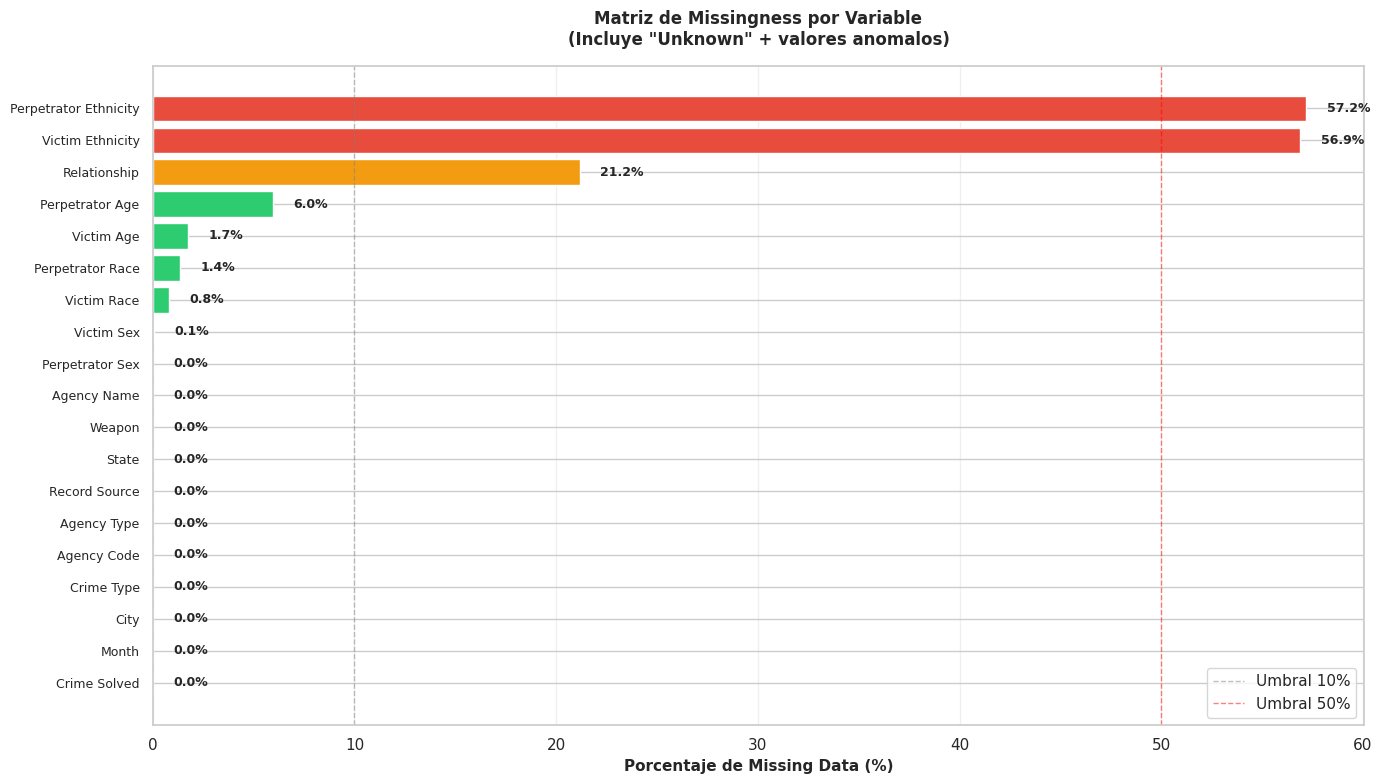

In [ ]:
# Visualización gráfica de Missingness
import numpy as np

fig, ax = plt.subplots(figsize=(14, 8))

# Preparar datos para visualización
missing_data = missing_summary.set_index('Variable')['Missing_Pct'].sort_values(ascending=True)

# Crear gráfico de barras horizontal
colors = ['#2ecc71' if x < 10 else '#f39c12' if x < 50 else '#e74c3c' for x in missing_data.values]
bars = ax.barh(range(len(missing_data)), missing_data.values, color=colors, edgecolor='white', linewidth=1)

ax.set_yticks(range(len(missing_data)))
ax.set_yticklabels(missing_data.index, fontsize=9)
ax.set_xlabel('Porcentaje de Missing Data (%)', fontsize=11, fontweight='bold')
ax.set_title('Matriz de Missingness por Variable\n(Incluye "Unknown" + valores anomalos)',
             fontsize=12, fontweight='bold', pad=15)

# Agregar valores en las barras
for i, (bar, val) in enumerate(zip(bars, missing_data.values)):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=9, fontweight='bold')

# Agregar línea de referencia
ax.axvline(x=10, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Umbral 10%')
ax.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Umbral 50%')

ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## <span style="color:Black;"><strong>9. Normalización de variables categóricas</strong></span>

In [ ]:
# Revisión de inconsistencias en categóricas

inconsistencias = {}

for col in categoricas:
    print(f"\n{col}:")

    # Contar espacios en blanco
    espacios = df_solved[col].str.contains(r'^\s+|\s+$', regex=True, na=False).sum()

    # Contar variaciones de caso
    unicos_case_sensitive = len(df_solved[col].unique())
    unicos_case_insensitive = len(df_solved[col].str.lower().unique())

    # Mostrar primeros valores únicos
    unicos_sample = df_solved[col].value_counts().head(5)

    print(f"   • Valores únicos: {len(df_solved[col].unique())}")
    print(f"   • Con espacios en blanco: {espacios}")
    print(f"   • Variaciones por caso: {unicos_case_sensitive - unicos_case_insensitive}")
    print(f"   • Top 5 valores:")
    for val, cnt in unicos_sample.items():
        pct = (cnt / len(df_solved)) * 100
        print(f"      - {val:30s}: {cnt:8,d} ({pct:5.2f}%)")

    inconsistencias[col] = {
        'espacios': espacios,
        'case_variations': unicos_case_sensitive - unicos_case_insensitive,
        'unicos': unicos_case_sensitive
    }


Agency Code:
   • Valores únicos: 11637
   • Con espacios en blanco: 0
   • Variaciones por caso: 0
   • Top 5 valores:
      - NY03030                       :   19,212 ( 4.29%)
      - CA01942                       :   15,975 ( 3.56%)
      - ILCPD00                       :   12,526 ( 2.79%)
      - MI82349                       :   10,750 ( 2.40%)
      - TXHPD00                       :   10,511 ( 2.35%)

Agency Name:
   • Valores únicos: 8932
   • Con espacios en blanco: 0
   • Variaciones por caso: 1
   • Top 5 valores:
      - New York                      :   19,212 ( 4.29%)
      - Los Angeles                   :   18,381 ( 4.10%)
      - Chicago                       :   12,526 ( 2.79%)
      - Detroit                       :   10,750 ( 2.40%)
      - Houston                       :   10,663 ( 2.38%)

Agency Type:
   • Valores únicos: 7
   • Con espacios en blanco: 0
   • Variaciones por caso: 0
   • Top 5 valores:
      - Municipal Police              :  336,009 (74.97%)
    

In [ ]:
# Aplicamos normalización: .lower() + .strip()

transformaciones_log = {}

for col in categoricas:
    # Crear versión normalizada
    df_solved[col] = df_solved[col].str.lower().str.strip()

    # Contar cambios
    unicos_despues = len(df_solved[col].unique())
    cambio = inconsistencias[col]['unicos'] - unicos_despues

    print(f"\n{col}:")
    print(f"   • Antes: {inconsistencias[col]['unicos']} valores únicos")
    print(f"   • Después: {unicos_despues} valores únicos")
    print(f"   • Reducción: {cambio} duplicados encontrados")

    transformaciones_log[col] = {
        'antes': inconsistencias[col]['unicos'],
        'despues': unicos_despues,
        'duplicados_detectados': cambio
    }

print("\nNORMALIZACIÓN COMPLETADA")
print(f"   • Variables procesadas: {len(categoricas)}")
print(f"   • Total duplicados por case/espacios: {sum([t['duplicados_detectados'] for t in transformaciones_log.values()])}")


Agency Code:
   • Antes: 11637 valores únicos
   • Después: 11637 valores únicos
   • Reducción: 0 duplicados encontrados

Agency Name:
   • Antes: 8932 valores únicos
   • Después: 8931 valores únicos
   • Reducción: 1 duplicados encontrados

Agency Type:
   • Antes: 7 valores únicos
   • Después: 7 valores únicos
   • Reducción: 0 duplicados encontrados

City:
   • Antes: 1775 valores únicos
   • Después: 1775 valores únicos
   • Reducción: 0 duplicados encontrados

State:
   • Antes: 50 valores únicos
   • Después: 50 valores únicos
   • Reducción: 0 duplicados encontrados

Month:
   • Antes: 12 valores únicos
   • Después: 12 valores únicos
   • Reducción: 0 duplicados encontrados

Crime Type:
   • Antes: 2 valores únicos
   • Después: 2 valores únicos
   • Reducción: 0 duplicados encontrados

Crime Solved:
   • Antes: 1 valores únicos
   • Después: 1 valores únicos
   • Reducción: 0 duplicados encontrados

Victim Sex:
   • Antes: 3 valores únicos
   • Después: 3 valores únicos
  

Tras la normalización aplicando `.lower()` + `.strip()` aseguramos que no haya duplicados por espacios, y se valida en todas las categorías.

## <span style="color:Black;"><strong>10. Validación de variables fecha</strong></span>

In [ ]:
# Diagnóstico de las columnas de fecha

fecha_cols = ['Year', 'Month']
fecha_encontradas = []

for col in fecha_cols:
    if col in df_solved.columns:
        fecha_encontradas.append(col)
        print(f"  {col} (tipo: {df_solved[col].dtype})")
        print(f"    • Valores únicos: {df_solved[col].nunique()}")
        print(f"    • Rango: {df_solved[col].min()} a {df_solved[col].max()}")
        print(f"    • Primeros 12 valores: {df_solved[col].value_counts().head(12).to_dict()}")

  Year (tipo: int64)
    • Valores únicos: 35
    • Rango: 1980 a 2014
    • Primeros 12 valores: {1980: 16729, 1993: 16435, 1992: 15881, 1994: 15881, 1981: 15788, 1991: 15321, 1982: 15060, 1990: 15001, 1986: 14820, 1983: 14515, 1995: 14370, 1989: 14179}
  Month (tipo: object)
    • Valores únicos: 12
    • Rango: april a september
    • Primeros 12 valores: {'july': 41468, 'august': 40805, 'january': 37951, 'may': 37851, 'june': 37817, 'september': 37804, 'december': 37229, 'october': 36896, 'march': 36640, 'april': 36613, 'november': 33840, 'february': 33258}


In [ ]:
# 3.2 Validación de rangos de fecha

# Validar Year
print(f"\nYear:")
year_range = (df_solved['Year'].min(), df_solved['Year'].max())
print(f"   • Rango: {year_range[0]} a {year_range[1]} (años)")
print(f"   • Años esperados: 1980-2014")
year_invalidos = df_solved[~df_solved['Year'].between(1900, 2100)].shape[0]
print(f"   • Valores fuera de rango (1900-2100): {year_invalidos}")

# Validar Month
print(f"\nMonth:")
print(f"   • Valores únicos: {sorted(df_solved['Month'].unique())}")
print(f"   • Distribución:")
for mes, cnt in df_solved['Month'].value_counts().sort_index().items():
    print(f"      • {mes}: {cnt:,} registros")

# Detectar valores problemáticos
month_validos = set(['january', 'february', 'march', 'april', 'may', 'june',
                      'july', 'august', 'september', 'october', 'november', 'december'])
month_invalidos = df_solved[~df_solved['Month'].isin(month_validos)]['Month'].unique()

if len(month_invalidos) > 0:
    print(f"\nALERTA: Meses inválidos detectados: {month_invalidos}")
else:
    print(f"\nTodos los meses son válidos")


Year:
   • Rango: 1980 a 2014 (años)
   • Años esperados: 1980-2014
   • Valores fuera de rango (1900-2100): 0

Month:
   • Valores únicos: ['april', 'august', 'december', 'february', 'january', 'july', 'june', 'march', 'may', 'november', 'october', 'september']
   • Distribución:
      • april: 36,613 registros
      • august: 40,805 registros
      • december: 37,229 registros
      • february: 33,258 registros
      • january: 37,951 registros
      • july: 41,468 registros
      • june: 37,817 registros
      • march: 36,640 registros
      • may: 37,851 registros
      • november: 33,840 registros
      • october: 36,896 registros
      • september: 37,804 registros

Todos los meses son válidos


Se valida que la información en las columnas que describen fechas sea correcta y no existan datos erróneos. No obstante, se decidió dejar estas columnas quietas, ya que falta el dato del día del incidente para hacer un posible mapeo a una sola variable tipo Date. En este caso, se optó por no asumir esta información.

## <span style="color:Black;"><strong>11. Validación de variables numéricas</strong></span>


In [ ]:
# Lista actualizada de numéricas
numericas_actualizado = df_solved.select_dtypes(include=['int64', 'float64']).columns.tolist()

validacion_numericas = []

for col in sorted(numericas_actualizado):
    print(f"\n{col}:")

    # Estadísticas básicas
    stats = df_solved[col].describe()
    print(f"   • Tipo: {df_solved[col].dtype}")
    print(f"   • Rango: [{stats['min']:.2f}, {stats['max']:.2f}]")
    print(f"   • Media: {stats['mean']:.2f}, Mediana: {df_solved[col].median():.2f}")
    print(f"   • Desv Est: {stats['std']:.2f}")
    print(f"   • Faltantes: {df_solved[col].isna().sum():,} ({df_solved[col].isna().sum()/len(df_solved)*100:.2f}%)")

    # Guardar resumen
    validacion_numericas.append({
        'Variable': col,
        'Tipo': df_solved[col].dtype,
        'Min': stats['min'],
        'Max': stats['max'],
        'Media': stats['mean'],
        'Missing': df_solved[col].isna().sum()
    })

# DataFrame de resumen
validacion_df = pd.DataFrame(validacion_numericas)
print(f"\nValidación completada para {len(validacion_df)} variables numéricas")


Incident:
   • Tipo: int64
   • Rango: [0.00, 999.00]
   • Media: 21.77, Mediana: 2.00
   • Desv Est: 93.32
   • Faltantes: 0 (0.00%)

Perpetrator Age:
   • Tipo: int64
   • Rango: [0.00, 99.00]
   • Media: 28.90, Mediana: 26.00
   • Desv Est: 14.36
   • Faltantes: 0 (0.00%)

Perpetrator Count:
   • Tipo: int64
   • Rango: [0.00, 10.00]
   • Media: 0.25, Mediana: 0.00
   • Desv Est: 0.68
   • Faltantes: 0 (0.00%)

Record ID:
   • Tipo: int64
   • Rango: [1.00, 638454.00]
   • Media: 316113.90, Mediana: 314868.50
   • Desv Est: 185797.70
   • Faltantes: 0 (0.00%)

Victim Age:
   • Tipo: int64
   • Rango: [0.00, 998.00]
   • Media: 34.01, Mediana: 30.00
   • Desv Est: 32.81
   • Faltantes: 0 (0.00%)

Victim Count:
   • Tipo: int64
   • Rango: [0.00, 10.00]
   • Media: 0.13, Mediana: 0.00
   • Desv Est: 0.58
   • Faltantes: 0 (0.00%)

Year:
   • Tipo: int64
   • Rango: [1980.00, 2014.00]
   • Media: 1995.63, Mediana: 1995.00
   • Desv Est: 10.00
   • Faltantes: 0 (0.00%)

Validación comp

## <span style="color:Black;"><strong>12. Detección de outliers con criterio <2% con IQR</strong></span>

In [ ]:
# Variables numéricas a analizar
vars_analizar_outliers = ['Victim Age', 'Perpetrator Age']

outlier_summary = []

for var in vars_analizar_outliers:
    print(f"\n{var}:")

    # Obtener datos válidos (no NaN)
    data = df_solved[var].dropna()

    # Calcular cuartiles
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Definir límites de outliers (método IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detectar outliers
    outliers_mask = (data < lower_bound) | (data > upper_bound)
    n_outliers = outliers_mask.sum()
    pct_outliers = (n_outliers / len(df_solved)) * 100

    print(f"   • Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"   • Límites IQR: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"   • Outliers detectados: {n_outliers:,} ({pct_outliers:.2f}%)")

    # Aplicar criterio <2%
    if pct_outliers < 2:
        print(f"CRITERIO <2% CUMPLIDO: Marcar para eliminación")
        accion = "ELIMINAR"
    else:
        print(f"CRITERIO NO CUMPLIDO: Mantener outliers (patrón real)")
        accion = "MANTENER"

    # Guardar resumen
    outlier_summary.append({
        'Variable': var,
        'N_Outliers': n_outliers,
        'Pct_Outliers': pct_outliers,
        'Accion': accion,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    })

# DataFrame de resumen
outlier_df = pd.DataFrame(outlier_summary)
print("\nRESUMEN DE OUTLIERS - Aplicando Criterio <2%")
print(outlier_df.to_string(index=False))


Victim Age:
   • Q1: 22.00, Q3: 42.00, IQR: 20.00
   • Límites IQR: [-8.00, 72.00]
   • Outliers detectados: 16,679 (3.72%)
CRITERIO NO CUMPLIDO: Mantener outliers (patrón real)

Perpetrator Age:
   • Q1: 20.00, Q3: 36.00, IQR: 16.00
   • Límites IQR: [-4.00, 60.00]
   • Outliers detectados: 14,076 (3.14%)
CRITERIO NO CUMPLIDO: Mantener outliers (patrón real)

RESUMEN DE OUTLIERS - Aplicando Criterio <2%
       Variable  N_Outliers  Pct_Outliers   Accion  Lower_Bound  Upper_Bound
     Victim Age       16679      3.721562 MANTENER         -8.0         72.0
Perpetrator Age       14076      3.140758 MANTENER         -4.0         60.0


**Método aplicado:** IQR (Rango Intercuartílico)
- **Fórmula:** Outliers = valores < (Q1 - 1.5 × IQR) o valores > (Q3 + 1.5 × IQR)

**Criterio < 2% aplicado**  por variable
- Si % outliers < 2% → Marcar para eliminación (casos raros)
- Si % outliers ≥ 2% → Mantener (patrón real)

En este caso, ninguno fue menor al 2%, por lo que se mantienen.

## <span style="color:Black;"><strong>13. Manejo de Missing Data</strong></span>

In [ ]:
# Evaluar missing data por variable - Aplicar criterio <2%

# Recalcular missing data después de transformaciones
missing_analysis = {}

# Para categóricas: contar "Unknown"
for col in df_solved.select_dtypes(include='object').columns:
    unknown_count = (df_solved[col] == "unknown").sum()
    pct = (unknown_count / len(df_solved)) * 100
    if unknown_count > 0:
        missing_analysis[col] = {
            'Type': 'Categorical (Unknown)',
            'Missing_Count': unknown_count,
            'Missing_Pct': pct,
            'Accion': 'ELIMINAR' if pct < 2 else 'MANTENER'
        }

# Para numéricas: contar NaN + valores centinela específicos
for col in ['Perpetrator Age', 'Victim Age', 'Victim Count', 'Perpetrator Count']:
    if col in df_solved.columns:
        nan_count = df_solved[col].isna().sum()
        centinela_count = ((df_solved[col] == 0) | (df_solved[col] > 100)).sum()

        total_missing = nan_count + centinela_count
        pct = (total_missing / len(df_solved)) * 100

        if total_missing > 0:
            missing_analysis[col] = {
                'Type': 'Numeric (NaN + Centinela)',
                'Missing_Count': total_missing,
                'Missing_Pct': pct,
                'Accion': 'ELIMINAR' if pct < 2 else 'MANTENER'
            }

# Mostrar análisis
print("\nMISSING DATA ANALYSIS - Criterio <2%:\n")
print(f"{'Variable':<30} | {'Type':<25} | {'Missing':<10} | {'%':<8} | {'Acción':<10}")
print("-" * 95)

for var, info in sorted(missing_analysis.items(), key=lambda x: x[1]['Missing_Pct'], reverse=True):
    print(f"{var:<30} | {info['Type']:<25} | {info['Missing_Count']:<10,d} | {info['Missing_Pct']:<8.2f} | {info['Accion']:<10}")

# Contar acciones
vars_a_eliminar = sum(1 for v in missing_analysis.values() if v['Accion'] == 'ELIMINAR')
vars_a_mantener = sum(1 for v in missing_analysis.values() if v['Accion'] == 'MANTENER')

print(f"Resumen: {vars_a_eliminar} variables con eliminación de filas, {vars_a_mantener} se mantienen")


MISSING DATA ANALYSIS - Criterio <2%:

Variable                       | Type                      | Missing    | %        | Acción    
-----------------------------------------------------------------------------------------------
Victim Count                   | Numeric (NaN + Centinela) | 410,234    | 91.53    | MANTENER  
Perpetrator Count              | Numeric (NaN + Centinela) | 374,769    | 83.62    | MANTENER  
Perpetrator Ethnicity          | Categorical (Unknown)     | 256,374    | 57.20    | MANTENER  
Victim Ethnicity               | Categorical (Unknown)     | 255,032    | 56.90    | MANTENER  
Relationship                   | Categorical (Unknown)     | 94,892     | 21.17    | MANTENER  
Perpetrator Age                | Numeric (NaN + Centinela) | 26,700     | 5.96     | MANTENER  
Victim Age                     | Numeric (NaN + Centinela) | 7,788      | 1.74     | ELIMINAR  
Perpetrator Race               | Categorical (Unknown)     | 6,049      | 1.35     | ELIMINAR  


In [ ]:
# Aplicar eliminación de filas según criterio <2%

# Inicializar máscara de filas a eliminar
rows_to_eliminate = pd.Series(False, index=df_solved.index)

for var, info in missing_analysis.items():
    if info['Accion'] == 'ELIMINAR':
        # Crear máscara de filas con missing en esta variable
        if var in df_solved.columns:
            if var in ['Perpetrator Age', 'Victim Age', 'Victim Count', 'Perpetrator Count']:
                # Numéricas
                if var == 'Perpetrator Age' or var == 'Victim Age':
                    missing_mask = (df_solved[var] == 0) | (df_solved[var] > 100)
                else:
                    missing_mask = (df_solved[var] == 0)
            else:
                # Categóricas
                missing_mask = (df_solved[var] == "unknown")

            n_filas = missing_mask.sum()
            rows_to_eliminate = rows_to_eliminate | missing_mask
            print(f"{var}: {n_filas:,} filas ELIMINADAS")

# Eliminar filas
df_clean = df_solved[~rows_to_eliminate].copy()

print(f"\nRESUMEN DE ELIMINACIÓN:")

print(f"\nRegistros antes: {len(df_solved):,}")
print(f"Registros eliminados: {rows_to_eliminate.sum():,} ({(rows_to_eliminate.sum()/len(df_solved)*100):.2f}%)")
print(f"Registros después: {len(df_clean):,}")
print(f"REDUCCIÓN TOTAL: {len(df_solved) - len(df_clean):,} filas")

Agency Name: 33 filas ELIMINADAS
Victim Sex: 331 filas ELIMINADAS
Victim Race: 3,592 filas ELIMINADAS
Perpetrator Sex: 147 filas ELIMINADAS
Perpetrator Race: 6,049 filas ELIMINADAS
Victim Age: 7,788 filas ELIMINADAS

RESUMEN DE ELIMINACIÓN:

Registros antes: 448,172
Registros eliminados: 15,780 (3.52%)
Registros después: 432,392
REDUCCIÓN TOTAL: 15,780 filas


Con el criterio del 2%, se debería mantener las columnas Victim Count, Perpetrator Count, Victim Ethnicity y Perpetrator Ethnicity. No obstante, se decide descartarlas.

Según la documentación asociada al dataset en Kaggle, las variables Victim Count y Perpetrator Count representan el número adicional de víctimas o perpetradores involucrados en la escena del crimen aparte del caso principal registrado. Sin embargo, al analizar su distribución original, se encontró que más de 500.000 registros presentaban el valor 0 en ambas columnas, lo que evidencia una variabilidad extremadamente baja dentro del conjunto de datos.

Por otro lado, las variables Victim Ethnicity y Perpetrator Ethnicity presentan más de un 50% de missing data. Imputar esto supondría un sesgo considerable.

Debido a este comportamiento, dichas variables aportaban poca información útil para identificar patrones relevantes o mejorar procesos posteriores de análisis. Por esta razón, se optó por excluirlas del proceso principal de análisis de datos.

In [ ]:
df_clean = df_clean.drop(columns=['Victim Count', 'Perpetrator Count', 'Victim Ethnicity', 'Perpetrator Ethnicity'])

Con este cambio hecho, solo habría que imputar las columnas Relationship y Perpetrator Age, siguiendo el criterio del < 2%

### <span style="color:Black;"><strong>13.1. Imputación de Relationship</strong></span>

In [ ]:
# Imputación de Relationship con la Moda

# Reemplazar 'Unknown' con NaN
df_clean['Relationship'] = df_clean['Relationship'].replace('unknown', np.nan)

# Imputar con la moda
moda = df_clean['Relationship'].mode()[0]
df_clean['Relationship'] = df_clean['Relationship'].fillna(moda)

### <span style="color:Black;"><strong>13.2. Imputación de Perpetrator Age</strong></span>

In [ ]:
# IMPUTACIÓN KNN para variables con ≥2% missing que se mantienen

from sklearn.impute import KNNImputer

impute_cols = ['Perpetrator Age']

# Crear subconjunto de datos para imputación
df_to_impute = df_clean[impute_cols].copy()

for col in impute_cols:
    df_to_impute[col] = df_to_impute[col].replace(0, np.nan)

print(f"\n   Antes de imputación:")
print(f"   • Valores faltantes totales: {df_to_impute.isna().sum().sum():,}")

# Aplicar KNN Imputer (con más vecinos debido a alta tasa de missing)
imputer = KNNImputer(n_neighbors=5, weights='distance')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_to_impute),
    columns=impute_cols,
    index=df_to_impute.index
)

# Reemplazar en df_clean
for col in impute_cols:
    df_clean[col] = df_imputed[col]
    df_clean[col] = df_clean[col].round().astype('int64')

print(f"\n   Después de imputación:")
print(f"   • Valores faltantes totales: {df_clean[impute_cols].isna().sum().sum()}")

print(f"\nESTADO FINAL:")
print(f"   • Dataset: {df_clean.shape[0]:,} registros × {df_clean.shape[1]} variables")


   Antes de imputación:
   • Valores faltantes totales: 23,308

   Después de imputación:
   • Valores faltantes totales: 0

ESTADO FINAL:
   • Dataset: 432,392 registros × 20 variables


## <span style="color:Black;"><strong>14. Codificación de Variables Categóricas</strong></span>

La columna Crime Solved es irrelevante ya que para este punto estamos trabajando únicamente con los casos resueltos.

In [ ]:
df_clean = df_clean.drop(columns=['Crime Solved'])

In [ ]:
# Análisis de cardinalidad - Decidir estrategia de codificación

# Categorías en df_clean (después de limpieza)
categoricas_limpias = df_clean.select_dtypes(include='object').columns.tolist()

# Identificar variables binarias (candidatas para Label Encoding simple)
variables_binarias = {'Crime Type', 'Victim Sex', 'Perpetrator Sex', 'Record Source'}
variables_ordinales = {'Month'}  # Variables con orden natural
variables_nominales = {'Agency Code', 'Agency Name', 'Agency Type', 'Perpetrator Race', 'Relationship', 'Victim Race', 'Weapon'}  # Variables sin orden

print(f"\nRESUMEN ESTRATEGIA RESPONSABLE:")
print(f"  • Binarias: {len(variables_binarias)} → Binary Encoding")
print(f"  • Ordinales: {len(variables_ordinales)} → Ordinal Encoding (preserva orden)")
print(f"  • Nominales: {len(variables_nominales)} → Label Encoding (evita curse of dimensionality)")


RESUMEN ESTRATEGIA RESPONSABLE:
  • Binarias: 4 → Binary Encoding
  • Ordinales: 1 → Ordinal Encoding (preserva orden)
  • Nominales: 7 → Label Encoding (evita curse of dimensionality)


In [ ]:
# Aplicar codificaciones

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

df_encoded = df_clean.copy()

print("\nCodificaciones: \n")

# Label encoding
label_cols = ['Crime Type', 'Victim Sex', 'Perpetrator Sex', 'Record Source', 'Agency Code', 'Agency Name', 'Agency Type', 'Perpetrator Race', 'Relationship', 'Victim Race', 'Weapon', 'State', 'City']

le = LabelEncoder()
for col in label_cols:
    df_encoded[col] = le.fit_transform(df_clean[col].astype(str))
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

#  Ordinal encoding
ordinal_cols = {'Month': ['january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november', 'december']}

oe = OrdinalEncoder(categories=list(ordinal_cols.values()))
df_encoded[list(ordinal_cols.keys())] = oe.fit_transform(df_clean[list(ordinal_cols.keys())]).astype('int64')


Shape antes del encoding: (432392, 19)

Codificaciones: 

Crime Type: {'manslaughter by negligence': np.int64(0), 'murder or manslaughter': np.int64(1)}
Victim Sex: {'female': np.int64(0), 'male': np.int64(1)}
Perpetrator Sex: {'female': np.int64(0), 'male': np.int64(1)}
Record Source: {'fbi': np.int64(0), 'foia': np.int64(1)}
Agency Code: {'ak00101': np.int64(0), 'ak00102': np.int64(1), 'ak00103': np.int64(2), 'ak00104': np.int64(3), 'ak00105': np.int64(4), 'ak00106': np.int64(5), 'ak00107': np.int64(6), 'ak00108': np.int64(7), 'ak00109': np.int64(8), 'ak00110': np.int64(9), 'ak00111': np.int64(10), 'ak00113': np.int64(11), 'ak00116': np.int64(12), 'ak00117': np.int64(13), 'ak00118': np.int64(14), 'ak00120': np.int64(15), 'ak00121': np.int64(16), 'ak00122': np.int64(17), 'ak00123': np.int64(18), 'ak00130': np.int64(19), 'ak00133': np.int64(20), 'ak00146': np.int64(21), 'ak00149': np.int64(22), 'ak00150': np.int64(23), 'ak00156': np.int64(24), 'akasp00': np.int64(25), 'akast01': np.in

## <span style="color:Black;"><strong>15. Validaciones finales y análisis de tendencias</strong></span>

In [ ]:
# Validación final de calidad

# Verificar Infinitos y NaNs
print(f"   • Valores NaN: {df_clean.isna().sum().sum()} (esperado: 0)")
print(f"   • Valores Infinitos: {np.isinf(df_clean.select_dtypes(include='number')).sum().sum()} (esperado: 0)")
print(f"   • Duplicados exactos: {df_clean.duplicated().sum()} filas")

   • Valores NaN: 0 (esperado: 0)
   • Valores Infinitos: 0 (esperado: 0)
   • Duplicados exactos: 0 filas



Promedio de homicidios por mes (años cubiertos: 35):

Mes          | Total      | Promedio/Año    | % Total 
--------------------------------------------------
january      | 36,663     | 1048            | 8.48    %
february     | 32,025     | 915             | 7.41    %
march        | 35,364     | 1010            | 8.18    %
april        | 35,307     | 1009            | 8.17    %
may          | 36,609     | 1046            | 8.47    %
june         | 36,578     | 1045            | 8.46    %
july         | 40,115     | 1146            | 9.28    %
august       | 39,412     | 1126            | 9.11    %
september    | 36,541     | 1044            | 8.45    %
october      | 35,503     | 1014            | 8.21    %
november     | 32,491     | 928             | 7.51    %
december     | 35,784     | 1022            | 8.28    %


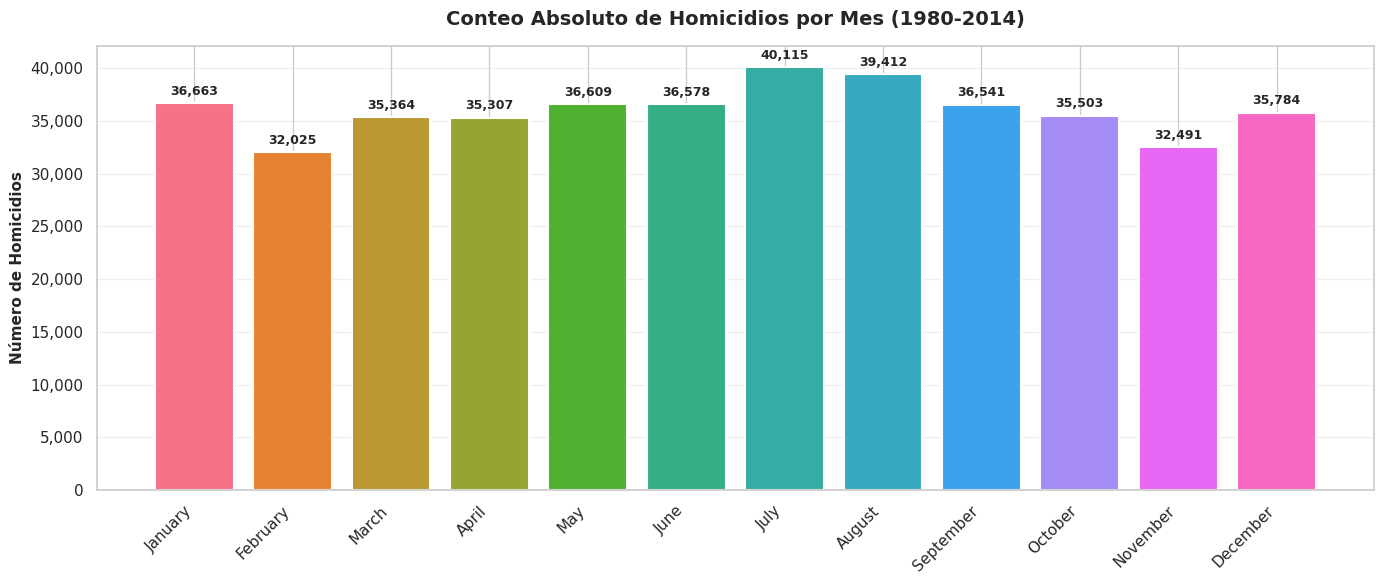

In [ ]:
# Conteo absoluto promedio por mes (Sin importar año)

# Mapeo de meses en inglés
orden_meses = ["january","february","march","april","may","june",
               "july","august","september","october","november","december"]

# Agrupar por mes (sin importar año)
homicidios_por_mes = df_clean.groupby('Month').size().reset_index(name='Total')
homicidios_por_mes['Mes_Num'] = homicidios_por_mes['Month'].map({m: i+1 for i, m in enumerate(orden_meses)})
homicidios_por_mes = homicidios_por_mes.sort_values('Mes_Num')

# Calcular promedio de años cubiertos por mes
n_anos = df_clean['Year'].max() - df_clean['Year'].min() + 1
homicidios_por_mes['Promedio_Anual'] = homicidios_por_mes['Total'] / n_anos

print(f"\nPromedio de homicidios por mes (años cubiertos: {n_anos}):\n")
print(f"{'Mes':<12} | {'Total':<10} | {'Promedio/Año':<15} | {'% Total':<8}")
print("-" * 50)

total_general = homicidios_por_mes['Total'].sum()
for _, row in homicidios_por_mes.iterrows():
    pct = (row['Total'] / total_general) * 100
    print(f"{row['Month']:<12} | {row['Total']:<10,.0f} | {row['Promedio_Anual']:<15.0f} | {pct:<8.2f}%")

# Crear visualización 1
fig, ax = plt.subplots(figsize=(14, 6))
colores = sns.color_palette("husl", len(homicidios_por_mes))
bars = ax.bar(range(len(homicidios_por_mes)), homicidios_por_mes['Total'],
              color=colores, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(homicidios_por_mes)))
ax.set_xticklabels(homicidios_por_mes['Month'].str.capitalize(), rotation=45, ha='right')
ax.set_title('Conteo Absoluto de Homicidios por Mes (1980-2014)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Número de Homicidios', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis='y', alpha=0.3)

# Agregar valores en barras
for bar, val in zip(bars, homicidios_por_mes['Total']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 500,
            f'{int(val):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


Primeros 5 años - Distribución porcentual por mes:

Month     april     august  december  february   january      july      june     march       may  november   october  september
Year                                                                                                                           
1980   7.774095  10.375883  7.830383  7.517668  8.030521  9.956845  8.599662  7.517668  8.130590  7.580211  8.136844   8.549628
1981   8.063057   8.851273  7.287763  8.185812  9.122626  8.999871  8.289185  8.941724  8.709136  7.488048  8.043675   8.017832
1982   8.231625   8.835096  7.824790  7.736642  8.658801  8.828316  8.435042  8.021427  8.828316  7.689178  8.312992   8.597776
1983   8.427283   8.617531  9.251691  7.673337  8.349775  9.033258  7.771984  8.638670  8.293405  7.313980  7.969278   8.659808
1984   8.155700   8.595922  9.182885  7.784986  8.433735  8.711770  7.993513  8.147977  7.893111  8.240655  8.580476   8.279271


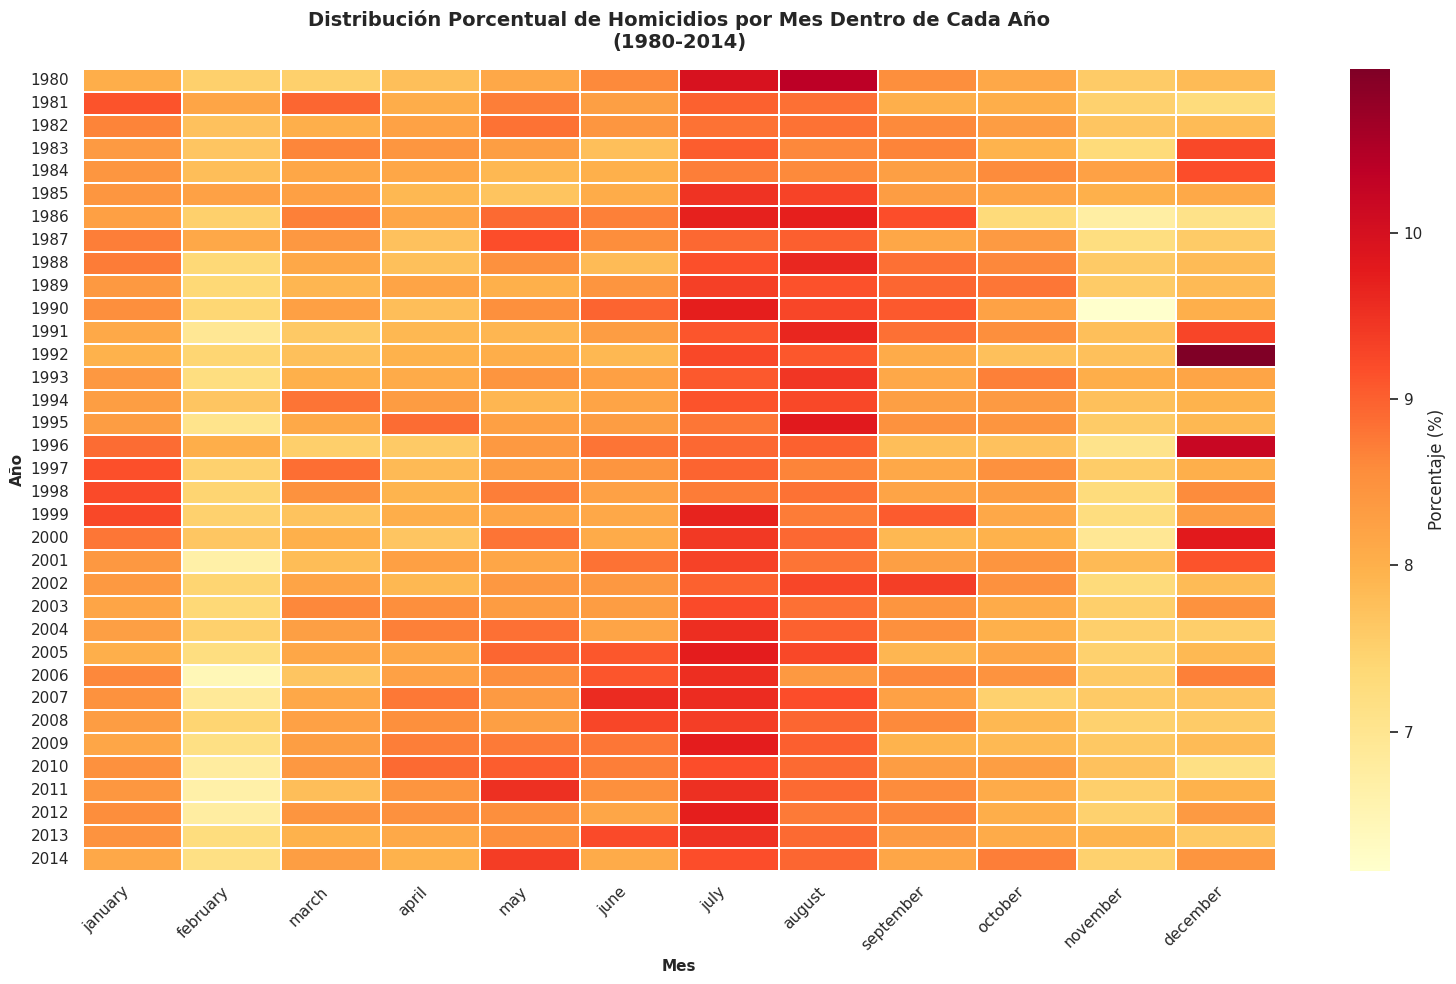

In [ ]:
# Distribución Porcentual Anual (% dentro de cada año)

# Crear tabla año × mes con porcentajes
pivot_pct = df_clean.groupby(['Year', 'Month']).size().unstack(fill_value=0)

# Convertir a porcentajes por año
pivot_pct_norm = pivot_pct.div(pivot_pct.sum(axis=1), axis=0) * 100

print(f"\nPrimeros 5 años - Distribución porcentual por mes:\n")
print(pivot_pct_norm.head().to_string())

# Crear visualización 2: Heatmap de % por año
fig, ax = plt.subplots(figsize=(16, 10))

# Reordenar columnas según orden de meses
cols_ordenadas = [m for m in orden_meses if m in pivot_pct_norm.columns]
pivot_pct_norm_ord = pivot_pct_norm[cols_ordenadas]

sns.heatmap(pivot_pct_norm_ord, cmap='YlOrRd', annot=False, fmt='.1f',
            cbar_kws={'label': 'Porcentaje (%)'}, ax=ax, linewidths=0.3)
ax.set_title('Distribución Porcentual de Homicidios por Mes Dentro de Cada Año\n(1980-2014)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mes', fontsize=11, fontweight='bold')
ax.set_ylabel('Año', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Homicidios por mes en intervalos de 5 años:

Month      january  february  march  april   may  june  july  august  september  october  november  december
Period_5y                                                                                                   
1980-1984     6250      5707   6050   5957  6149  6040  6697    6668       6177     6014      5610      6036
1985-1989     5737      5211   5591   5373  5713  5626  6299    6324       5874     5566      5008      5187
1990-1994     6290      5580   6157   6104  6211  6329  7038    7101       6446     6326      5717      6761
1995-1999     5259      4414   4792   4763  4927  4947  5292    5324       4890     4845      4332      5069
2000-2004     4415      3851   4305   4322  4472  4402  4887    4713       4476     4315      3910      4482
2005-2009     4548      3836   4420   4630  4685  5007  5241    4890       4516     4361      4136      4336
2010-2014     4164      3426   4049   4158  4452  4227  4661    4392       4162   

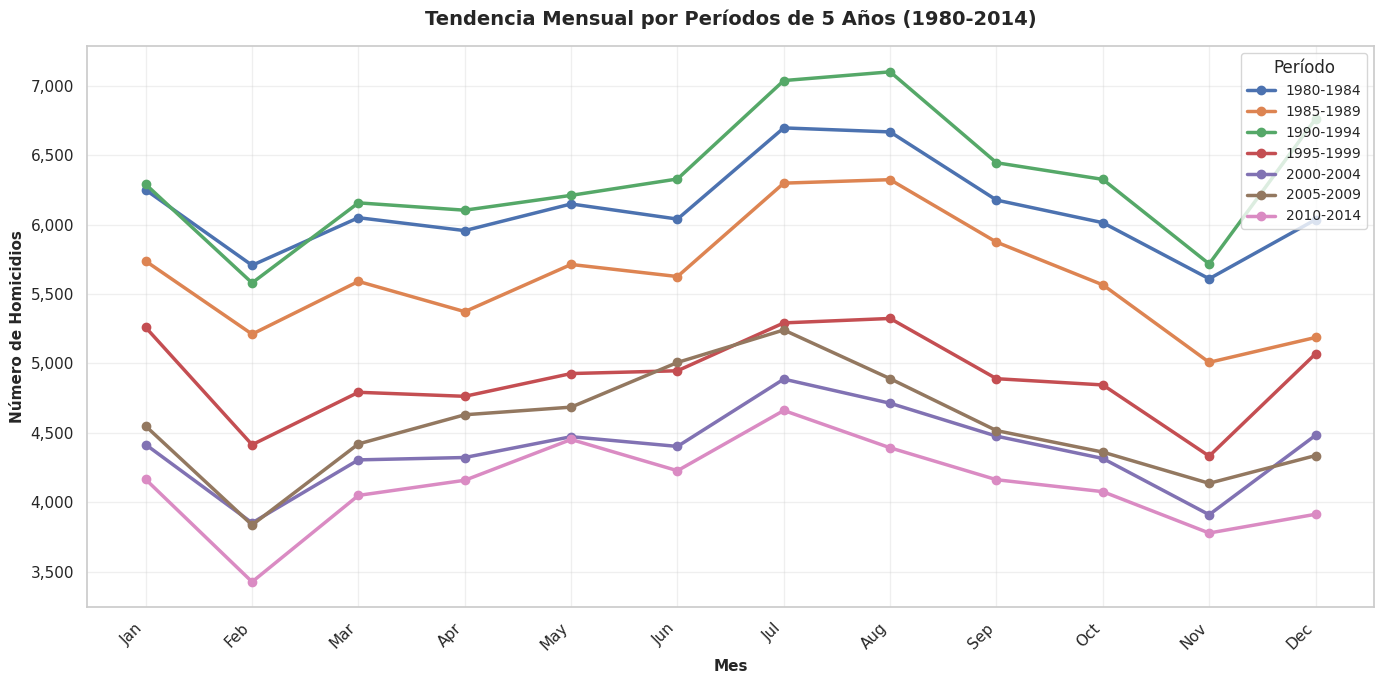

In [ ]:
# Comparación año a año, cada 5 años

# Crear grupos de 5 años
def get_period(year):
    return f"{(year // 5) * 5}-{(year // 5) * 5 + 4}"

df_clean['Period_5y'] = df_clean['Year'].apply(get_period)

# Agrupar por periodo × mes
pivot_5y = df_clean.groupby(['Period_5y', 'Month']).size().unstack(fill_value=0)
pivot_5y = pivot_5y[[m for m in orden_meses if m in pivot_5y.columns]]

print(f"\nHomicidios por mes en intervalos de 5 años:\n")
print(pivot_5y.to_string())

# Crear visualización 3: Gráfico línea comparativo
fig, ax = plt.subplots(figsize=(14, 7))

meses_num = range(1, 13)
for period in pivot_5y.index:
    ax.plot(meses_num, pivot_5y.loc[period].values, marker='o', linewidth=2.5,
            label=period, markersize=6)

ax.set_xticks(meses_num)
ax.set_xticklabels([m.capitalize()[:3] for m in orden_meses], rotation=45, ha='right')
ax.set_title('Tendencia Mensual por Períodos de 5 Años (1980-2014)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mes', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Homicidios', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title='Período', loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Homicidios por mes según género de la víctima:

Victim Sex  female   male
Month                    
january       8980  27683
february      8213  23812
march         8818  26546
april         8851  26456
may           8904  27705
june          8702  27876
july          9373  30742
august        9337  30075
september     8823  27718
october       8507  26996
november      7900  24591
december      8877  26907


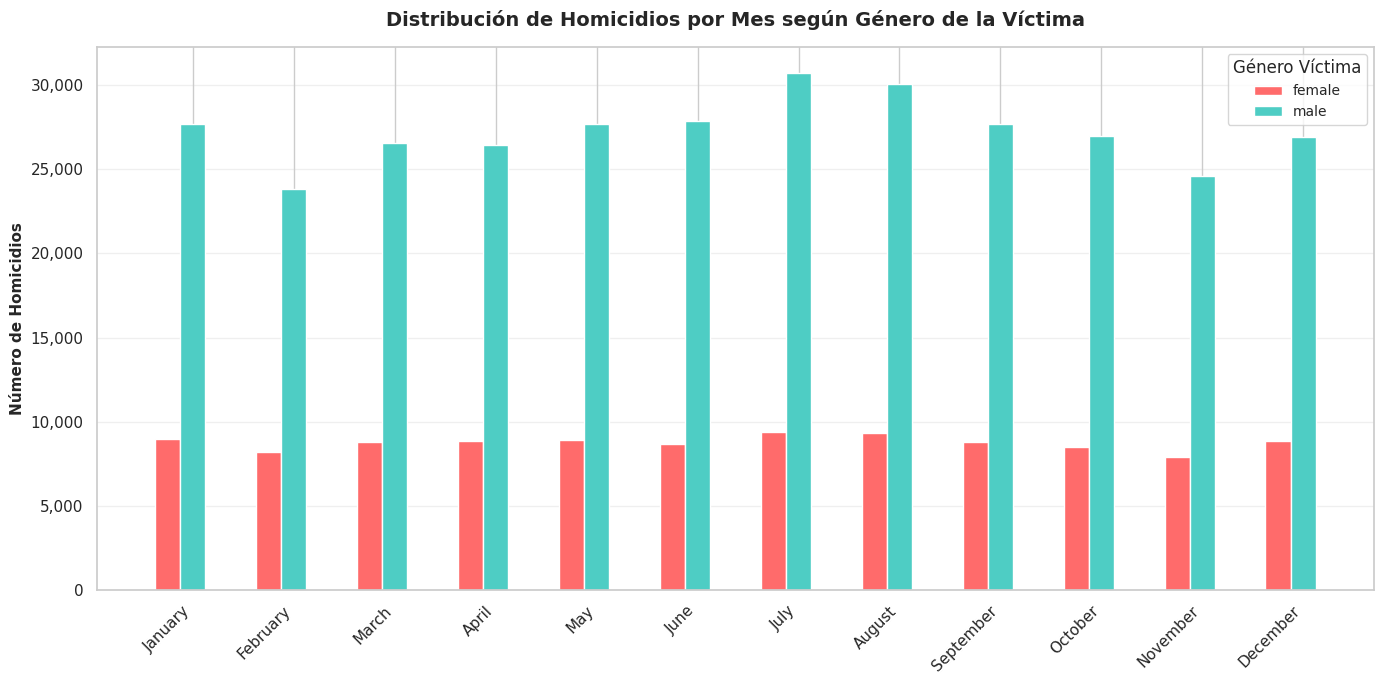

In [ ]:
# Tendencia global de mes x género

# Agrupar por mes × gender de víctima
pivot_gender = df_clean.groupby(['Month', 'Victim Sex']).size().unstack(fill_value=0)
pivot_gender = pivot_gender.loc[[m for m in orden_meses if m in pivot_gender.index]]

print(f"\nHomicidios por mes según género de la víctima:\n")
print(pivot_gender.to_string())

# Crear visualización 4: Gráfico agrupado por género
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(pivot_gender))
width = 0.25
colors_gender = ['#FF6B6B', '#4ECDC4', '#95A5A6']

for i, gender in enumerate(pivot_gender.columns):
    offset = (i - 1) * width
    ax.bar(x + offset, pivot_gender[gender], width, label=gender, color=colors_gender[i], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in pivot_gender.index], rotation=45, ha='right')
ax.set_title('Distribución de Homicidios por Mes según Género de la Víctima', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Número de Homicidios', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title='Género Víctima', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Top 3 tipos de crimen:
   1. murder or manslaughter: 424,276 (98.12%)
   2. manslaughter by negligence: 8,116 (1.88%)

Homicidios por mes según tipo de crimen (Top 3):

Crime Type  manslaughter by negligence  murder or manslaughter
Month                                                         
january                            701                   35962
february                           640                   31385
march                              688                   34676
april                              663                   34644
may                                642                   35967
june                               677                   35901
july                               747                   39368
august                             693                   38719
september                          589                   35952
october                            664                   34839
november                           730                   31761
december   

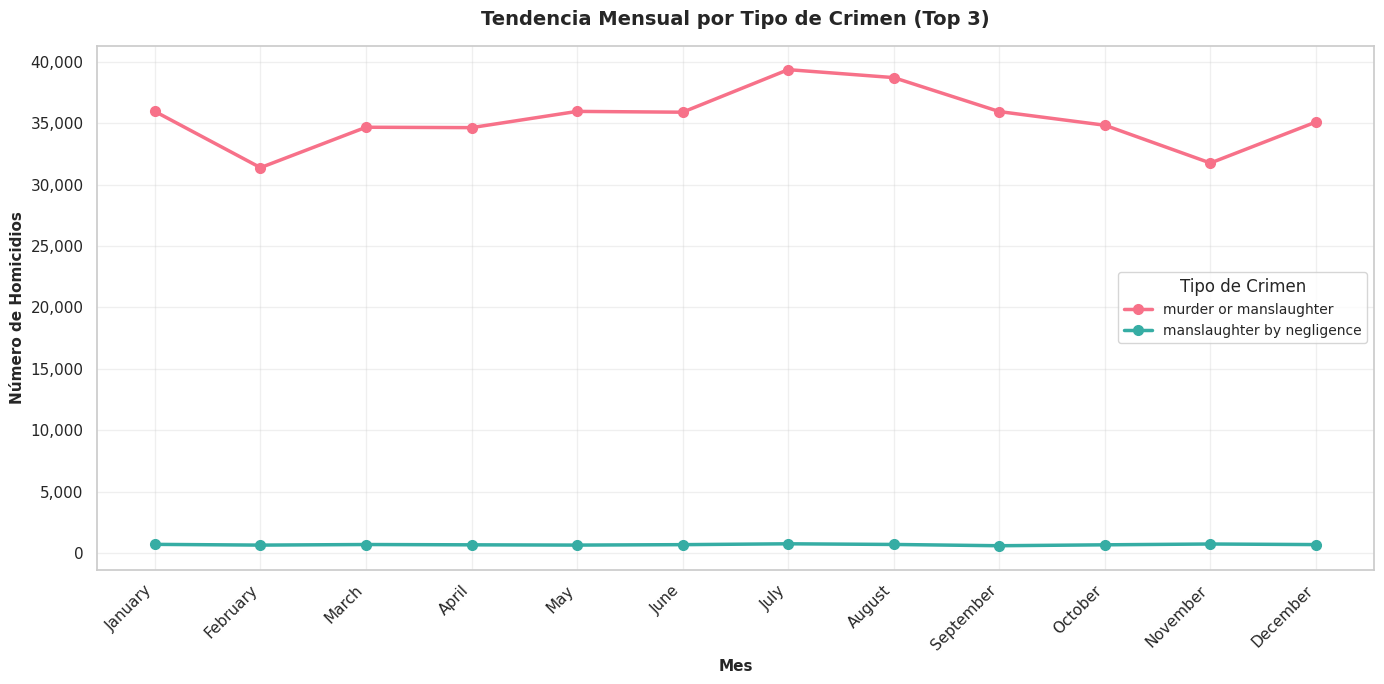


✓ Gráfico 5 generado


In [ ]:
# Tendencia global de mes x tipo de crimen (Top 3)

# Identificar top 3 tipos de crimen
top_crimes = df_clean['Crime Type'].value_counts().head(3).index.tolist()
print(f"\nTop 3 tipos de crimen:")
for i, crime in enumerate(top_crimes, 1):
    count = (df_clean['Crime Type'] == crime).sum()
    pct = (count / len(df_clean)) * 100
    print(f"   {i}. {crime}: {count:,} ({pct:.2f}%)")

# Filtrar data para top 3 crímenes
df_top_crimes = df_clean[df_clean['Crime Type'].isin(top_crimes)]

# Agrupar por mes × crime type
pivot_crimes = df_top_crimes.groupby(['Month', 'Crime Type']).size().unstack(fill_value=0)
pivot_crimes = pivot_crimes.loc[[m for m in orden_meses if m in pivot_crimes.index]]

print(f"\nHomicidios por mes según tipo de crimen (Top 3):\n")
print(pivot_crimes.to_string())

# Crear visualización 5: Gráfico línea para top 3 crímenes
fig, ax = plt.subplots(figsize=(14, 7))

meses_num = range(1, len(pivot_crimes) + 1)
colors_crimes = sns.color_palette("husl", len(top_crimes))

for i, crime in enumerate(top_crimes):
    if crime in pivot_crimes.columns:
        ax.plot(meses_num, pivot_crimes[crime].values, marker='o', linewidth=2.5,
                label=crime, color=colors_crimes[i], markersize=7)

ax.set_xticks(meses_num)
ax.set_xticklabels([m.capitalize() for m in pivot_crimes.index], rotation=45, ha='right')
ax.set_title('Tendencia Mensual por Tipo de Crimen (Top 3)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mes', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de Homicidios', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title='Tipo de Crimen', fontsize=10, loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Gráfico 5 generado")

In [ ]:
# Interpretaciones y Hallazgos

# Análisis de variabilidad
mes_max = homicidios_por_mes.loc[homicidios_por_mes['Total'].idxmax()]
mes_min = homicidios_por_mes.loc[homicidios_por_mes['Total'].idxmin()]
variabilidad = (homicidios_por_mes['Total'].max() - homicidios_por_mes['Total'].min()) / homicidios_por_mes['Total'].mean() * 100

print(f"\nHALLAZGOS CLAVE:\n")
print(f"1. MES CON MÁS HOMICIDIOS:")
print(f"   • {mes_max['Month'].capitalize()}: {mes_max['Total']:,.0f} registros ({(mes_max['Total']/total_general*100):.2f}% del total)")

print(f"\n2. MES CON MENOS HOMICIDIOS:")
print(f"   • {mes_min['Month'].capitalize()}: {mes_min['Total']:,.0f} registros ({(mes_min['Total']/total_general*100):.2f}% del total)")

print(f"\n3. VARIABILIDAD ESTACIONAL:")
print(f"   • Rango: {mes_max['Total'] - mes_min['Total']:,.0f} homicidios")
print(f"   • Variabilidad: {variabilidad:.1f}% (respecto a promedio)")

print(f"\n4. PATRÓN POR GÉNERO:")
if 'male' in pivot_gender.columns:
    pct_male = (pivot_gender['male'].sum() / pivot_gender.sum().sum()) * 100
    print(f"   • Víctimas masculinas: {pct_male:.1f}%")

print(f"\n5. PATRONES POR TIPO DE CRIMEN (Top 3):")
for i, crime in enumerate(top_crimes, 1):
    if crime in pivot_crimes.columns:
        print(f"   • {crime}: {pivot_crimes[crime].sum():,.0f} registros")


HALLAZGOS CLAVE:

1. MES CON MÁS HOMICIDIOS:
   • July: 40,115 registros (9.28% del total)

2. MES CON MENOS HOMICIDIOS:
   • February: 32,025 registros (7.41% del total)

3. VARIABILIDAD ESTACIONAL:
   • Rango: 8,090 homicidios
   • Variabilidad: 22.5% (respecto a promedio)

4. PATRÓN POR GÉNERO:
   • Víctimas masculinas: 75.7%

5. PATRONES POR TIPO DE CRIMEN (Top 3):
   • murder or manslaughter: 424,276 registros
   • manslaughter by negligence: 8,116 registros


## <span style="color:Black;"><strong>16. Export del dataset limpio</strong></span>

<class 'pandas.core.frame.DataFrame'>
Index: 432392 entries, 0 to 638452
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Record ID         432392 non-null  int64  
 1   Agency Code       432392 non-null  int64  
 2   Agency Name       432392 non-null  int64  
 3   Agency Type       432392 non-null  int64  
 4   City              432392 non-null  int64  
 5   State             432392 non-null  int64  
 6   Year              432392 non-null  int64  
 7   Month             432392 non-null  float64
 8   Incident          432392 non-null  int64  
 9   Crime Type        432392 non-null  int64  
 10  Victim Sex        432392 non-null  int64  
 11  Victim Age        432392 non-null  int64  
 12  Victim Race       432392 non-null  int64  
 13  Perpetrator Sex   432392 non-null  int64  
 14  Perpetrator Age   432392 non-null  int64  
 15  Perpetrator Race  432392 non-null  int64  
 16  Record Source     432392 

In [ ]:
# EXPORT DE DATASET LIMPIO Y METADATOS

# Guardar dataset limpio (sin codificaciones, sin features ML)
export_path = "homicide_clean.csv"
df_encoded.to_csv(export_path, index=False)

print(f"\nDataset limpio exportado: {export_path}")
print(f"  • Filas: {len(df_encoded):,}")
print(f"  • Columnas: {df_encoded.shape[1]}")

# Crear metadata
metadata = {
    'dataset_name': 'Homicide Data - Cleaned & Prepared',
    'original_records': len(df),
    'final_records': len(df_encoded),
    'records_removed': len(df) - len(df_encoded),
    'percent_removed': ((len(df) - len(df_encoded)) / len(df)) * 100,
    'total_variables': df_encoded.shape[1]
}

print(f"\nRESUMEN DE LIMPIEZA:")
print(f"   • Registros originales: {metadata['original_records']:,}")
print(f"   • Registros finales: {metadata['final_records']:,}")
print(f"   • Eliminados: {metadata['records_removed']:,} ({metadata['percent_removed']:.2f}%)")
print(f"   • Total de variables: {metadata['total_variables']:,}")


Dataset limpio exportado: homicide_clean.csv
  • Filas: 432,392
  • Columnas: 19

RESUMEN DE LIMPIEZA:
   • Registros originales: 638,454
   • Registros finales: 432,392
   • Eliminados: 206,062 (32.28%)
   • Total de variables: 19


## <span style="color:Black;"><strong>Referencias</strong></span>

El desarrollo de este proyecto permitió evidenciar la importancia de seguir adecuadamente las fases del ciclo de vida del análisis de datos, ya que cada etapa contribuye significativamente a mejorar la comprensión, calidad y confiabilidad de la información procesada. Comprender inicialmente el contexto del problema y el objetivo del análisis facilitó identificar cuáles variables eran relevantes, qué tipo de comportamientos podían esperarse y qué dificultades podían presentarse dentro del dataset. Este entendimiento del negocio y de la problemática constituye un punto de partida fundamental para orientar correctamente las decisiones analíticas y evitar interpretaciones erróneas de los datos.

Asimismo, la etapa de exploración y preparación de los datos demostró ser una de las fases más críticas dentro del proceso. La aplicación de análisis exploratorio de datos (EDA), junto con técnicas univariadas, bivariadas y multivariadas, permitió identificar patrones relevantes, relaciones entre variables, distribuciones, anomalías y posibles sesgos presentes en la información. Procesos como la detección de datos atípicos, normalización, transformación de variables continuas y categóricas, así como la estandarización de formatos, contribuyeron a construir un conjunto de datos más consistente y preparado para futuros análisis predictivos.

Uno de los principales desafíos encontrados estuvo relacionado con el volumen de información del dataset y la alta presencia de valores Unknown o datos faltantes, especialmente en variables asociadas al perpetrador. Este comportamiento resultó coherente con la naturaleza de los homicidios y de las investigaciones criminales, particularmente en los casos no resueltos, donde gran parte de la información del victimario es desconocida. En este sentido, la decisión de trabajar únicamente con casos resueltos permitió reducir considerablemente la cantidad de datos faltantes y mejorar la calidad general del análisis. Además, el apoyo de documentación y foros asociados al dataset en Kaggle fue fundamental para comprender el significado de ciertas variables y tomar decisiones más acertadas durante el preprocesamiento.

Los resultados obtenidos también permitieron identificar comportamientos relevantes dentro de los homicidios registrados en Estados Unidos entre 1980 y 2014. Se observaron patrones asociados al sexo de las víctimas, predominando significativamente los casos en hombres, así como una fuerte presencia del uso de armas de fuego tipo handgun en la mayoría de los homicidios. De igual forma, se identificaron concentraciones temporales importantes en determinados años y meses, además de diferencias considerables entre estados respecto a tasas de homicidios y resolución de casos. Estos hallazgos evidencian cómo el análisis de datos puede aportar información útil para comprender fenómenos sociales complejos y detectar tendencias relevantes dentro de grandes volúmenes de información.

Finalmente, este trabajo deja abiertas múltiples posibilidades de mejora y extensión futura. Como continuación del proyecto, podrían implementarse modelos predictivos o técnicas de machine learning que permitan estimar probabilidades de resolución de casos, identificar patrones de comportamiento criminal o detectar factores asociados a determinados tipos de homicidios. También sería posible incorporar nuevas fuentes de información externas, como variables socioeconómicas, con el objetivo de enriquecer el análisis y obtener una comprensión más profunda del fenómeno estudiado. De igual manera, futuras investigaciones podrían explorar modelos temporales o espaciales que permitan analizar la evolución de los homicidios a lo largo del tiempo y su distribución geográfica dentro de Estados Unidos.

## <span style="color:Black;"><strong>Referencias</strong></span>

### **Fuente de los datos**
**Dataset recuperado de:** [Homicide](https://www.kaggle.com/code/harshilahalpara/homicide).  
**Autor:** HARSHIL AHALPARA.


**Autores originales:** Murder Accountability Project y Abigail Larion.  
**Repositorio:** [Homicide Reports, 1980-2014](https://www.kaggle.com/datasets/murderaccountability/homicide-reports/data).  